In [ ]:
## Analysis of inflow outputs for renal cell carcinoma dataset
## Dr Daniyal Jafree, Lotfollahi Group, CellGen Programme, Wellcome Sanger Institute
## Analysis of previously published scRNAseq data to recover Mintflow signatures + cell-cell communciation analysis
## Final Version - 20th July 2025

In [90]:
## Load up packages and set up environment
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
import anndata as ad
from sklearn.decomposition import PCA
from scipy import sparse
import liana as li
import decoupler as dc
import plotnine as p9
from matplotlib.colors import ListedColormap, LinearSegmentedColormap
from matplotlib import cm
import matplotlib.colors as mcolors
import seaborn as sns
from liana.mt import rank_aggregate
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean

# Version check and set seed
sc.logging.print_versions()
sc.set_figure_params(facecolor="white", figsize=(8, 8))
sc.settings.verbosity = 3
sc.settings.seed = 0

/var/folders/d5/cm_lb26s4hqcvy9l5h9g7gjm0000gn/T/ipykernel_36433/143963133.py:22: FutureWarning: Use `print_header` instead


In [2]:
## Load the AnnData object derived from https://data.mendeley.com/datasets/g67bkbnhhg/1

adata = sc.read_h5ad("/Users/daniyaljafree/Desktop/scRNAseq_analyses/Lotfollahi_RCC/RCC_upload_final_raw_counts.h5ad")
print(adata)

AnnData object with n_obs × n_vars = 270855 × 19736
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'patient', 'percent.mt', 'summaryDescription', 'annotation', 'region', 'broad_type'
    var: 'name'
    uns: 'annotation_colors', 'broad_type_colors', 'region_colors', 'summaryDescription_colors'
    obsm: 'X_pca', 'X_umap'


In [3]:
## Tidy up to only include RCC tumour samples

adata = adata[~adata.obs['patient'].isin(['PD44714', 'PD47172'])].copy() # Subset adata to exclude patients with oncocytoma
adata = adata[adata.obs['summaryDescription'].isin(['Tumour'])].copy() # Subset adata to only include normal kidney, tumour, and interface (i.e. tumour-normal)
print(adata) #check it has worked

AnnData object with n_obs × n_vars = 147917 × 19736
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'patient', 'percent.mt', 'summaryDescription', 'annotation', 'region', 'broad_type'
    var: 'name'
    uns: 'annotation_colors', 'broad_type_colors', 'region_colors', 'summaryDescription_colors'
    obsm: 'X_pca', 'X_umap'


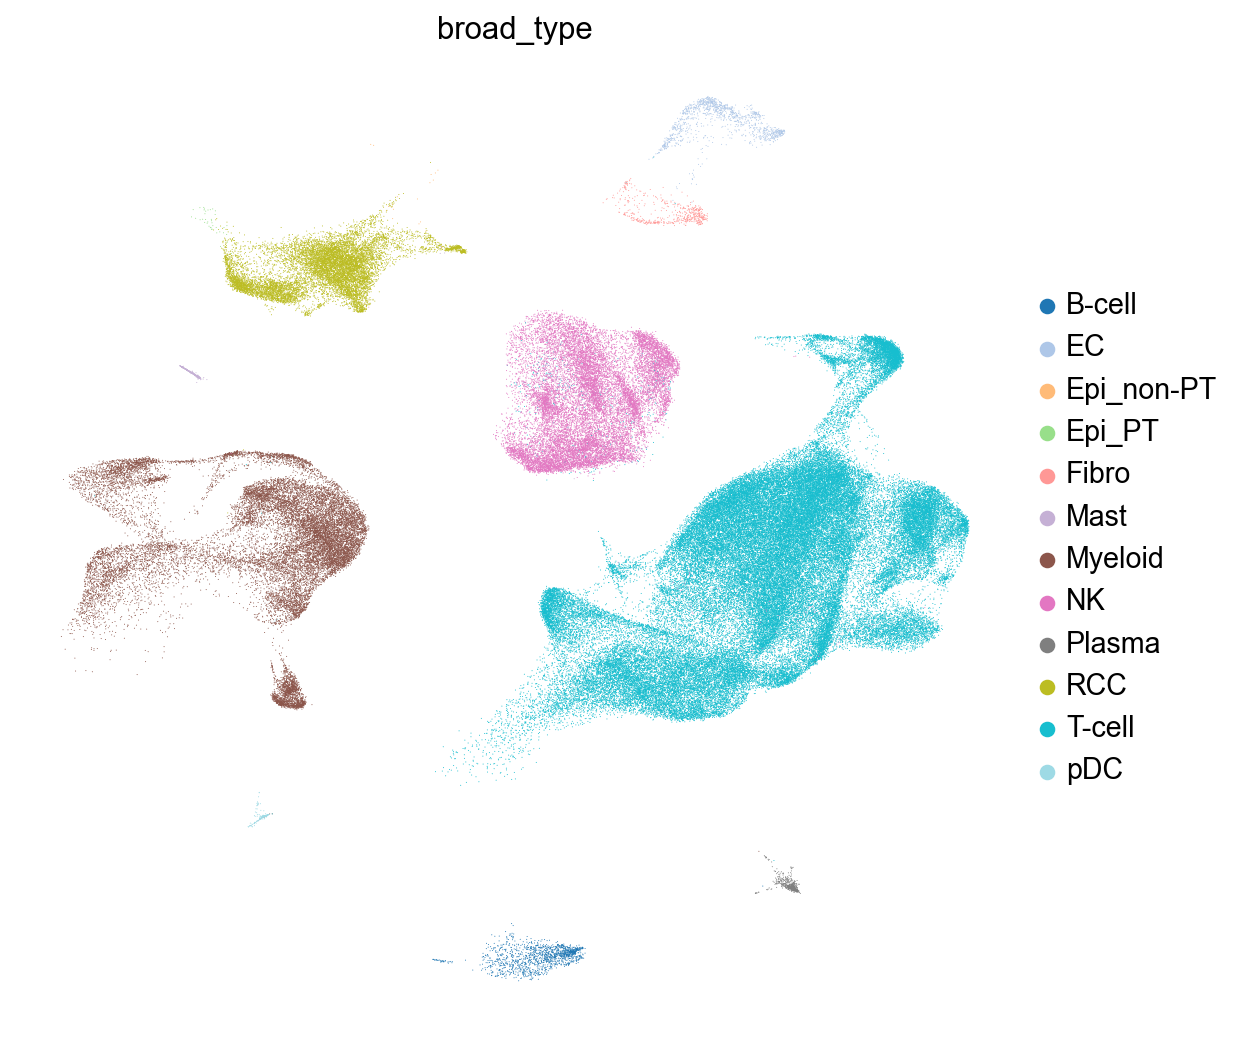

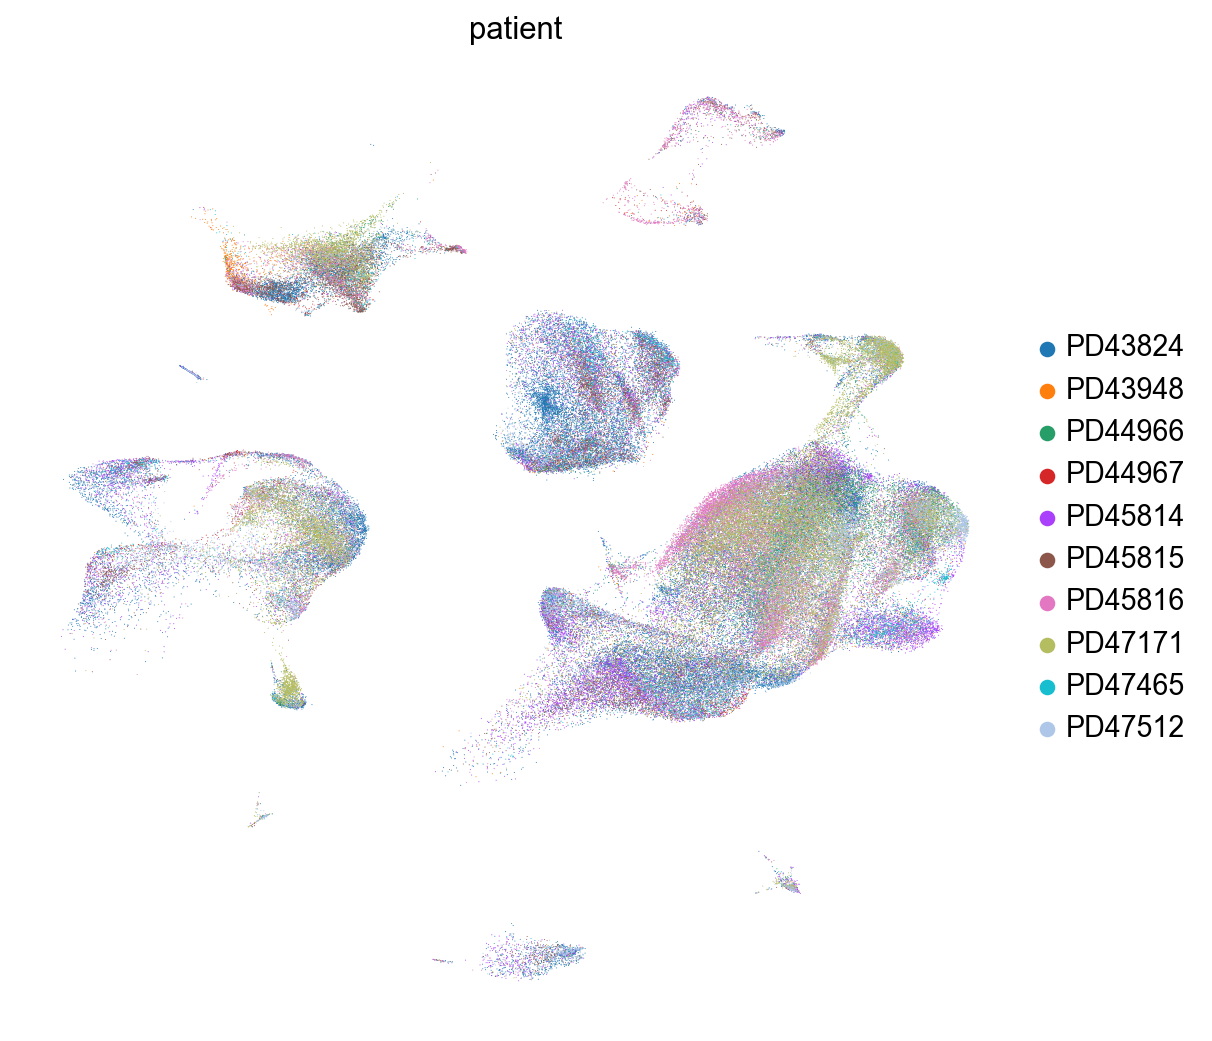

In [4]:
### GENERATES FIGURE 6A

## Data inspection

sc.pl.umap(adata, color=['broad_type'], frameon=False) # Visualize according to whicever desired metadata you want
sc.pl.umap(adata, color=['patient'], frameon=False)

In [301]:
## Add clinical information

# Manually create the clinical metadata dictionary
clinical_data_dict = {
    'patient': [
        'PD43824', 'PD43948', 'PD44966', 'PD44967', 'PD45814', 
        'PD45815', 'PD45816', 'PD47171', 'PD47465', 'PD47512'
    ],
    'clinical_info': [
        'cancer stage 1b, grade 2, Leibovich score 2',
        'cancer stage 3a, grade 4, Leibovich score 8',
        'cancer stage 1a, grade 3, Leibovich score 1',
        'grade 4, Leibovich score 8',
        'cancer stage 3a, grade 4, Leibovich score 8',
        'cancer stage 3a, grade 2, Leibovich score 4',
        'cancer stage 3a, grade 4, Leibovich score 9',
        'cancer stage 3a, grade 4, Leibovich score 7',
        'cancer stage 3a, grade 3, Leibovich score 5',
        'cancer stage 3a, grade 4, Leibovich score 8'
    ]
}

# Convert dictionary to DataFrame
clinical_data = pd.DataFrame(clinical_data_dict)

# Function to process clinical information
def process_clinical_info(info):
    if pd.isna(info):  # Handle missing values
        return pd.Series([None, None, None, None])

    # Extract cancer stage
    if "stage 1" in info:
        stage = "1"
    elif "stage 3" in info:
        stage = "3"
    else:
        stage = None

    # Extract Leibovich score
    if "Leibovich score" in info:
        leibovich_score_str = info.split("Leibovich score")[1].strip()
        try:
            leibovich_score = int(leibovich_score_str)
        except ValueError:
            leibovich_score = None
    else:
        leibovich_score = None

    # Extract grade
    if "grade 2" in info:
        grade = "2"
    elif "grade 3" in info:
        grade = "3"
    elif "grade 4" in info:
        grade = "4"
    else:
        grade = None

    # Classify risk (updated logic!)
    if leibovich_score is not None:
        if leibovich_score <= 2:
            leibovich_risk = "Low Risk"
        elif 3 <= leibovich_score <= 5:
            leibovich_risk = "Intermediate Risk"
        else:
            leibovich_risk = "High Risk"
    else:
        leibovich_risk = None

    return pd.Series([stage, grade, str(leibovich_score) if leibovich_score is not None else None, leibovich_risk])

# Apply function to process the clinical data
clinical_data[['cancer_stage', 'grade', 'Leibovich_score', 'Leibovich_risk']] = clinical_data['clinical_info'].apply(process_clinical_info)

# Explicit type conversion
clinical_data['Leibovich_score'] = clinical_data['Leibovich_score'].astype(str)
clinical_data['grade'] = clinical_data['grade'].astype(str)

# View result
print(clinical_data)

   patient                                clinical_info cancer_stage grade  \
0  PD43824  cancer stage 1b, grade 2, Leibovich score 2            1     2   
1  PD43948  cancer stage 3a, grade 4, Leibovich score 8            3     4   
2  PD44966  cancer stage 1a, grade 3, Leibovich score 1            1     3   
3  PD44967                   grade 4, Leibovich score 8         None     4   
4  PD45814  cancer stage 3a, grade 4, Leibovich score 8            3     4   
5  PD45815  cancer stage 3a, grade 2, Leibovich score 4            3     2   
6  PD45816  cancer stage 3a, grade 4, Leibovich score 9            3     4   
7  PD47171  cancer stage 3a, grade 4, Leibovich score 7            3     4   
8  PD47465  cancer stage 3a, grade 3, Leibovich score 5            3     3   
9  PD47512  cancer stage 3a, grade 4, Leibovich score 8            3     4   

  Leibovich_score     Leibovich_risk  
0               2           Low Risk  
1               8          High Risk  
2               1       

In [302]:
# Drop existing columns in adata.obs if they exist
columns_to_drop = ['cancer_stage', 'grade', 'Leibovich_score', 'Leibovich_risk']
adata.obs = adata.obs.drop(columns=[col for col in columns_to_drop if col in adata.obs.columns], errors='ignore')

# Now merge based on the patient ID
adata.obs = adata.obs.merge(
    clinical_data[['patient', 'cancer_stage', 'grade', 'Leibovich_score', 'Leibovich_risk']], 
    on='patient', 
    how='left'
)

# Verify the merge
print(adata.obs[['patient', 'cancer_stage', 'grade', 'Leibovich_score', 'Leibovich_risk']].head())

   patient cancer_stage grade Leibovich_score Leibovich_risk
0  PD43948            3     4               8      High Risk
1  PD43948            3     4               8      High Risk
2  PD43948            3     4               8      High Risk
3  PD43948            3     4               8      High Risk
4  PD43948            3     4               8      High Risk


... storing 'patient' as categorical
... storing 'cancer_stage' as categorical
... storing 'grade' as categorical
... storing 'Leibovich_score' as categorical
... storing 'Leibovich_risk' as categorical


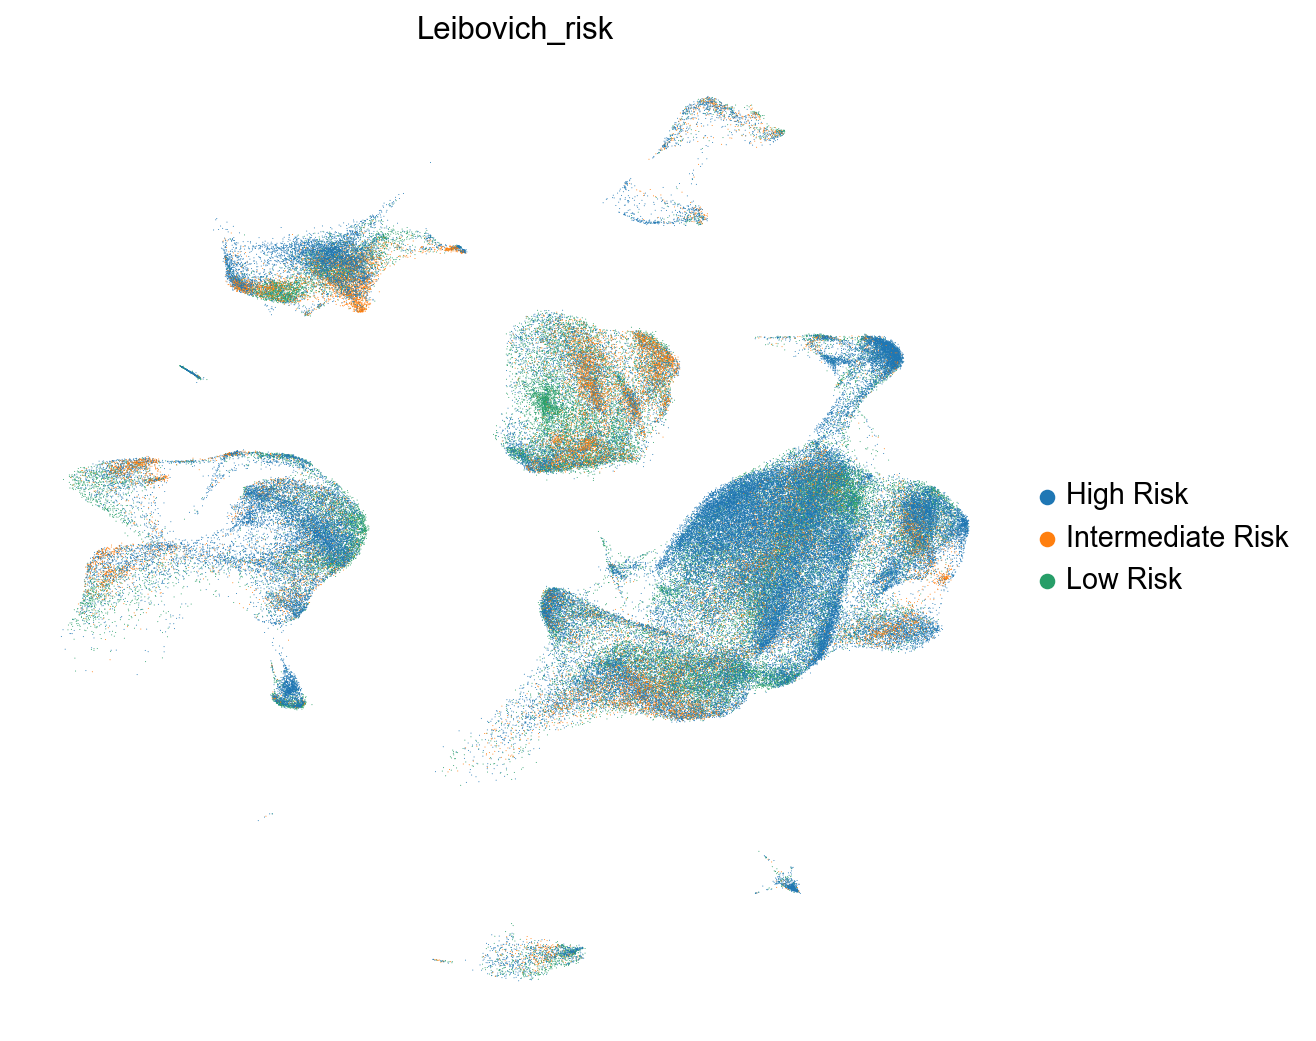

In [303]:
sc.pl.umap(adata, color=['Leibovich_risk'], frameon=False) # Visualize according to whicever desired metadata you want

In [304]:
# Define genes of interest based on Mintflow MGPs

#CD8+ TLS core 1
gene_set1 = ['TAP1', 'IL2RG', 'CD2', 'STAT1', 'RASGRP1', 'GBP5', 'CD27', 'NLRC5', 'CD3E', 'ITGA4', 'CXCR3', 'PDE4DIP', 'ANGPTL4', 'THEMIS', 'LDHA', 'CD247', 'IRF1', 'GPR174', 'HNRNPLL', 'IKZF3', 'OGT', 'GZMK', 'SPN', 'NAP1L4', 'CD44', 'PLCG1', 'IKZF1', 'ITGAL', 'CD3G', 'RASSF5', 'CD5', 'PKM', 'SLFN5', 'EGLN3', 'BTN3A1', 'LAG3', 'CD8A', 'TAP2', 'ZAP70', 'ITGB2', 'LCK', 'GBP1', 'SIRPG', 'APOL6', 'APOBEC3C', 'ITM2A', 'SEMA4D', 'PFKP', 'TSPAN14', 'SELPLG', 'JAK3', 'ADAR', 'MIAT', 'APOBEC3G', 'CD96', 'DDX6', 'CHD3', 'IL10RA', 'SDHA', 'CD6', 'SH2D2A', 'CYLD', 'LAT', 'CSK', 'IL16', 'TNFRSF14', 'ITK', 'UBASH3A', 'GZMA', 'CD82', 'TNFRSF1B', 'CCR5', 'SLAMF6', 'FYN', 'CYFIP2', 'HNRNPD', 'OAS3', 'PTPRJ', 'NDRG1', 'BCL11B', 'GRK2', 'ACAP1', 'LRBA', 'DNM2', 'MDFIC', 'PRKCH', 'PIK3CD', 'MBNL1', 'CD84', 'HDAC1', 'DIP2A', 'PLIN2', 'TRAF5', 'PVT1', 'ERAP1', 'HSPA8', 'PRDM1', 'STK4', 'PBXIP1', 'HNRNPF']

#CD8+ TLS core 2
gene_set2 = ['CD14', 'SLCO2B1', 'MSR1', 'CD163', 'LGMN', 'MAFB', 'CSF1R', 'STAB1', 'SIGLEC1', 'CD68', 'GRN', 'CYBB', 'SLC40A1', 'SDC3', 'CPVL', 'SPI1', 'LIPA', 'CIITA', 'AP1B1', 'CREG1', 'NCF1', 'CD4', 'GAA', 'FCGR2A', 'CTSL', 'NCOA4', 'MAN2B1', 'TRPM2', 'CTSC', 'HCK', 'SGK1', 'C3AR1', 'TYMP', 'LGALS9', 'ITGAX', 'TBXAS1', 'FMN1', 'CXCL16', 'TREM2', 'LAIR1', 'PFKFB3', 'ST14', 'THEMIS2', 'CYP27A1', 'VSIG4', 'CD84', 'SCPEP1', 'GAS6', 'GPR34', 'LAG3', 'FCGR3A', 'CMKLR1', 'KCNMA1', 'CYBA', 'SLC7A7', 'MAN1A1', 'ARRB2', 'ABCA1', 'DAPK1', 'WARS', 'CSF3R', 'AXL', 'NAIP', 'ITGB2', 'CEBPA', 'TKT', 'MX1', 'PLAUR', 'STAT1', 'HMOX1', 'FCGR1A', 'CTSH', 'SOAT1', 'FOLR2', 'FERMT3', 'GRB2', 'F13A1', 'MRC2', 'TLR4', 'IL10RA', 'ACP5', 'BLVRA', 'NCF2', 'GBP1', 'CCR1', 'PLEKHM2', 'UCP2', 'PGD', 'LILRB1', 'FUCA1', 'GBP5', 'TNFSF13', 'CD38', 'LAMP1', 'SLAMF8', 'RASSF4', 'IFNGR1', 'HEXA', 'MRC1', 'LTA4H']

#CD8+ TLS border
gene_set3 = ["APOL1", "UBD", "CXCL9", "APOL2", "WARS", "GBP1", "SERPINE1", "TGM2", "RRAD", "IFIT3", "ENPP3", "VCAM1", "CXCL10", "ICAM1", "CXCL11", "ANGPTL4", "IRF1", "OAS1", "ITGA3", "TAP1", "CA12", "IFIT2", "TNFSF10", "APOL6", "CX3CL1", "MX1", "OAS3", "CFB", "C4B", "GBP5", "C4A", "IFI35", "STAT1", "CLDN1", "TYMP", "EGLN3", "CA9", "CP", "NPTX2", "MET", "CD70", "TFPI2", "HSPB8", "IFITM1", "EGFR", "LDHA", "AXL", "IFIT1", "ADM", "SLC37A4", "NFE2L3", "SPATS2L", "CDK18", "PFKP", "CDH6", "TRIM47", "CDKN1A", "ENPEP", "LAG3", "CD40", "NFE2L1", "STAT2", "IFI44L", "SLC5A3", "ANXA5", "RNF128", "TOP1", "PLIN2", "ANPEP", "BCL2L1", "TRAFD1", "ANXA2", "CD8A", "PLXNB2", "VEGFA", "PTPRF", "SLC16A4", "SDC4", "TNFRSF21", "TRIM21", "CCND1", "SLC2A1", "PLSCR1", "EIF5A", "ACLY", "TAP2", "SOCS3", "PDIA3", "HERC6", "PML", "SCIN", "DPP4", "GSTO1", "DDX58", "TNIP1", "APOL3", "LOX", "SEZ6L2", "FLNB", "RSAD2"]

#TLS macrophage
gene_set4 = ['CYP27A1', 'STAT1', 'GBP5', 'WARS', 'SDC3', 'GBP1', 'LIPA', 'TAP1', 'NR1H3', 'ACP5', 'CD38', 'SCPEP1', 'SLAMF7', 'IFIT3', 'SIGLEC1', 'CTSL', 'MX1', 'CXCL9', 'IGF2R', 'TYMP', 'LGMN', 'LTA4H', 'APOL6', 'IRF1', 'CTSC', 'SOAT1', 'PLA2G7', 'LGALS9', 'STAT2', 'CD82', 'OAS3', 'CREG1', 'CEBPA', 'APOL2', 'GLA', 'ITGAL', 'CD68', 'PGD', 'TAP2', 'ITGAX', 'GSTO1', 'ADGRE5', 'CCR1', 'UCP2', 'TNFRSF14', 'NLRC5', 'IFIT2', 'BLVRA', 'CXCL10', 'IFI35', 'SNX10', 'SGSH', 'DMXL2', 'ANXA2', 'CMKLR1', 'VAMP5', 'CTSA', 'ZFYVE26', 'FERMT3', 'STK40', 'IDH1', 'CD84', 'APOL3', 'PLAUR', 'CD72', 'G6PD', 'ACE', 'GRB2', 'PLEKHM2', 'FUCA1', 'APOL1', 'MRC2', 'CORO1C', 'NCF2', 'NCEH1', 'TREM2', 'NCF1', 'IFI44L', 'OAS1', 'STAT5A', 'SLAMF8', 'PKD2L1', 'SLC29A3', 'ABCD1', 'UBD', 'PDIA3', 'PLEKHB2', 'RAB7A', 'HMOX1', 'NPC1', 'MARCO', 'SGK1', 'FKBP15', 'FBP1', 'P2RX7', 'MAP7D1', 'PFKFB3', 'MVP', 'LILRB3', 'GLB1']


sc.tl.score_genes(adata, gene_list=gene_set1, score_name='CD8+ TLS core 1 signature') # Compute the module score
sc.tl.score_genes(adata, gene_list=gene_set2, score_name='CD8+ TLS core 2 signature') # Compute the module score
sc.tl.score_genes(adata, gene_list=gene_set3, score_name='CD8+ TLS border signature') # Compute the module score
sc.tl.score_genes(adata, gene_list=gene_set4, score_name='TLS macrophage signature') # Compute the module score

# Verify module scores
print(adata.obs[['CD8+ TLS core 1 signature']].head())
print(adata.obs[['CD8+ TLS core 2 signature']].head())
print(adata.obs[['CD8+ TLS border signature']].head())
print(adata.obs[['TLS macrophage signature']].head())

computing score 'CD8+ TLS core 1 signature'
    finished: added
    'CD8+ TLS core 1 signature', score of gene set (adata.obs).
    494 total control genes are used. (0:00:00)
computing score 'CD8+ TLS core 2 signature'
    finished: added
    'CD8+ TLS core 2 signature', score of gene set (adata.obs).
    742 total control genes are used. (0:00:00)
computing score 'CD8+ TLS border signature'
    finished: added
    'CD8+ TLS border signature', score of gene set (adata.obs).
    794 total control genes are used. (0:00:00)
computing score 'TLS macrophage signature'
    finished: added
    'TLS macrophage signature', score of gene set (adata.obs).
    845 total control genes are used. (0:00:00)
   CD8+ TLS core 1 signature
0                  -0.022388
1                  -0.016766
2                   0.007439
3                   0.011907
4                  -0.009448
   CD8+ TLS core 2 signature
0                  -0.008139
1                   0.035886
2                   0.004889
3       

In [306]:
# Define thresholds for high module score
threshold_CD8_TLS_core_1_signature = 0.5
threshold_CD8_TLS_core_2_signature = 0.5
threshold_CD8_TLS_Tborder_signature = 0.5
threshold_TLS_macborder_signature = 0.5

# Count number of cells with module_score > threshold per patient

# For CD8_TLS_core_1_signature
CD8_TLS_core_1_counts = adata.obs[adata.obs['CD8+ TLS core 1 signature'] > threshold_CD8_TLS_core_1_signature].groupby('patient').size().reset_index(name='CD8_TLS_core_1_counts')

# For CD8_TLS_core_2_signature
CD8_TLS_core_2_counts = adata.obs[adata.obs['CD8+ TLS core 2 signature'] > threshold_CD8_TLS_core_2_signature].groupby('patient').size().reset_index(name='CD8_TLS_core_2_counts')

# For CD8_TLS_Tborder_signature
CD8_TLS_Tborder_counts = adata.obs[adata.obs['CD8+ TLS border signature'] > threshold_CD8_TLS_Tborder_signature].groupby('patient').size().reset_index(name='CD8_TLS_Tborder_counts')

# For TLS_macborder_signature
TLS_macborder_counts = adata.obs[adata.obs['TLS macrophage signature'] > threshold_TLS_macborder_signature].groupby('patient').size().reset_index(name='TLS_macborder_counts')

# Merge with clinical metadata (Leibovich risk & Grade)
patient_clinical_data = adata.obs[['patient', 'Leibovich_risk', 'grade']].drop_duplicates()

CD8_TLS_core_1_counts = CD8_TLS_core_1_counts.merge(patient_clinical_data, on='patient', how='left')
CD8_TLS_core_2_counts = CD8_TLS_core_2_counts.merge(patient_clinical_data, on='patient', how='left')
CD8_TLS_Tborder_counts = CD8_TLS_Tborder_counts.merge(patient_clinical_data, on='patient', how='left')
TLS_macborder_counts = TLS_macborder_counts.merge(patient_clinical_data, on='patient', how='left')

# Check outputs
print(CD8_TLS_core_1_counts.head())
print(CD8_TLS_core_2_counts.head())
print(CD8_TLS_Tborder_counts.head())
print(TLS_macborder_counts.head())

   patient  CD8_TLS_core_1_counts Leibovich_risk grade
0  PD43824                      0       Low Risk     2
1  PD43948                      0      High Risk     4
2  PD44966                      0       Low Risk     3
3  PD44967                      0      High Risk     4
4  PD45814                      0      High Risk     4
   patient  CD8_TLS_core_2_counts Leibovich_risk grade
0  PD43824                      0       Low Risk     2
1  PD43948                      0      High Risk     4
2  PD44966                      0       Low Risk     3
3  PD44967                      0      High Risk     4
4  PD45814                      0      High Risk     4
   patient  CD8_TLS_Tborder_counts Leibovich_risk grade
0  PD43824                       0       Low Risk     2
1  PD43948                       0      High Risk     4
2  PD44966                       0       Low Risk     3
3  PD44967                       0      High Risk     4
4  PD45814                       0      High Risk     4
   p

/var/folders/d5/cm_lb26s4hqcvy9l5h9g7gjm0000gn/T/ipykernel_36433/2577234447.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/d5/cm_lb26s4hqcvy9l5h9g7gjm0000gn/T/ipykernel_36433/2577234447.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/d5/cm_lb26s4hqcvy9l5h9g7gjm0000gn/T/ipykernel_36433/2577234447.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
/var/folders/d5/cm_lb26s4hqcvy9l5h9g7gjm000

computing score 'CD8+ TLS core 1 signature_Tcells'


/Users/daniyaljafree/Desktop/scRNAseq_analyses/Lotfollahi_RCC/RCC_DJ_VENV/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.


    finished: added
    'CD8+ TLS core 1 signature_Tcells', score of gene set (adata.obs).
    545 total control genes are used. (0:00:00)
computing score 'CD8+ TLS core 2 signature_Tcells'
    finished: added
    'CD8+ TLS core 2 signature_Tcells', score of gene set (adata.obs).
    997 total control genes are used. (0:00:00)
computing score 'CD8+ TLS border signature_Tcells'
    finished: added
    'CD8+ TLS border signature_Tcells', score of gene set (adata.obs).
    1040 total control genes are used. (0:00:00)


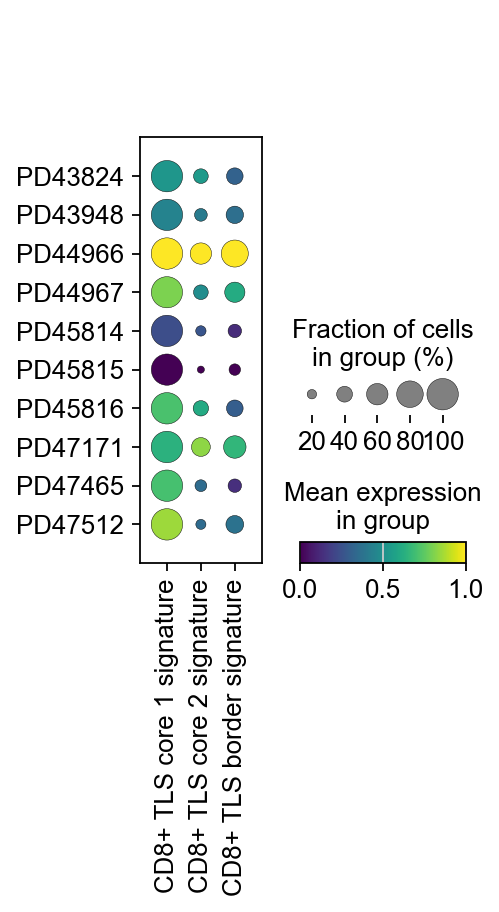

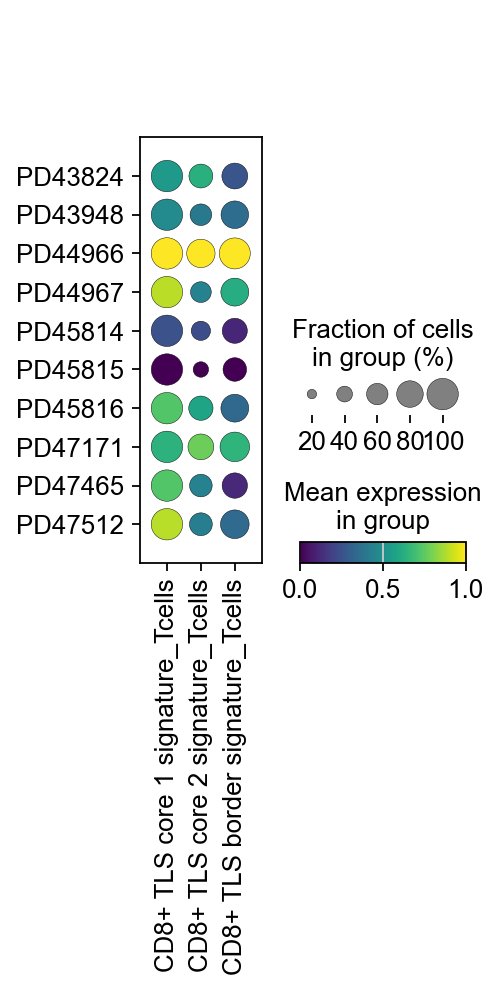

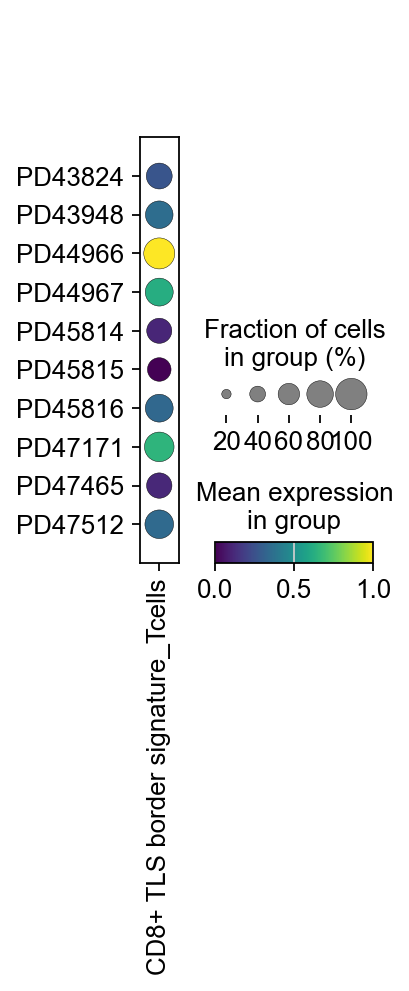

/var/folders/d5/cm_lb26s4hqcvy9l5h9g7gjm0000gn/T/ipykernel_36433/968173605.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


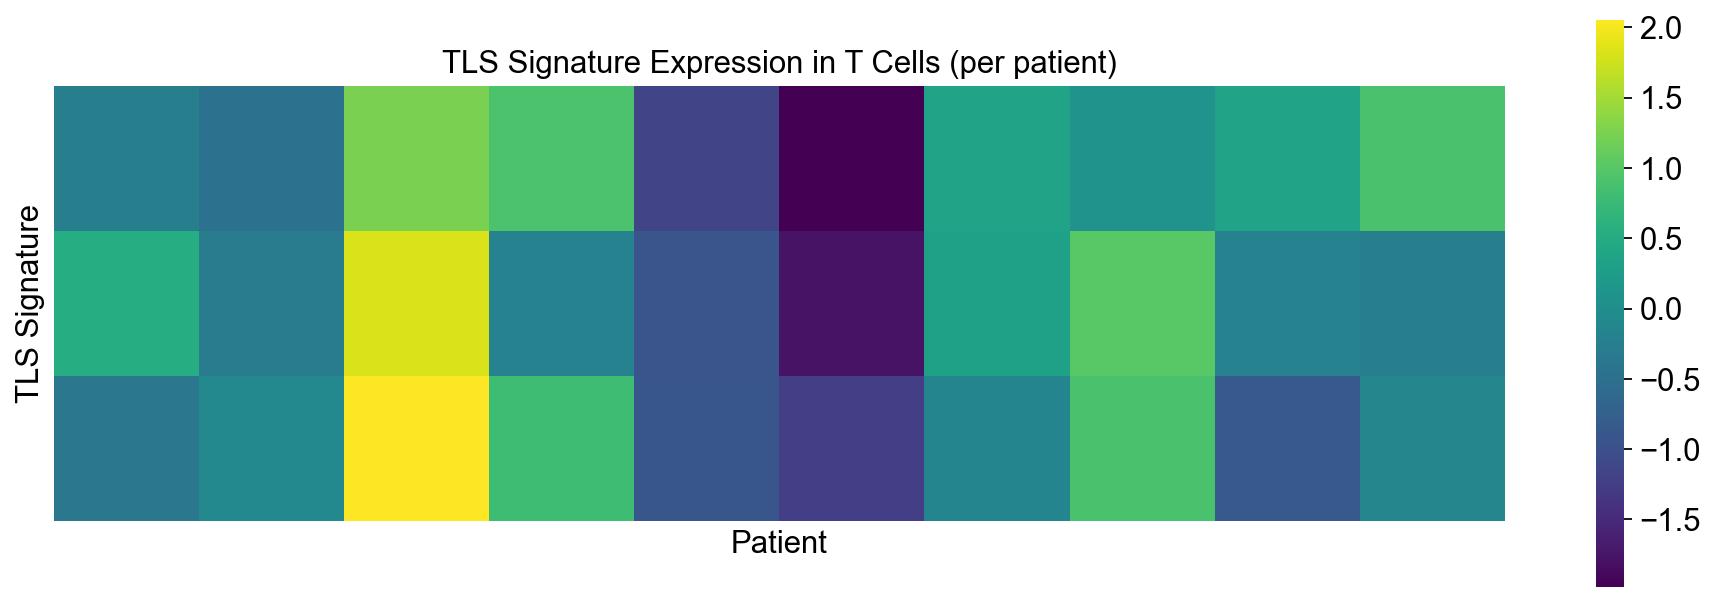

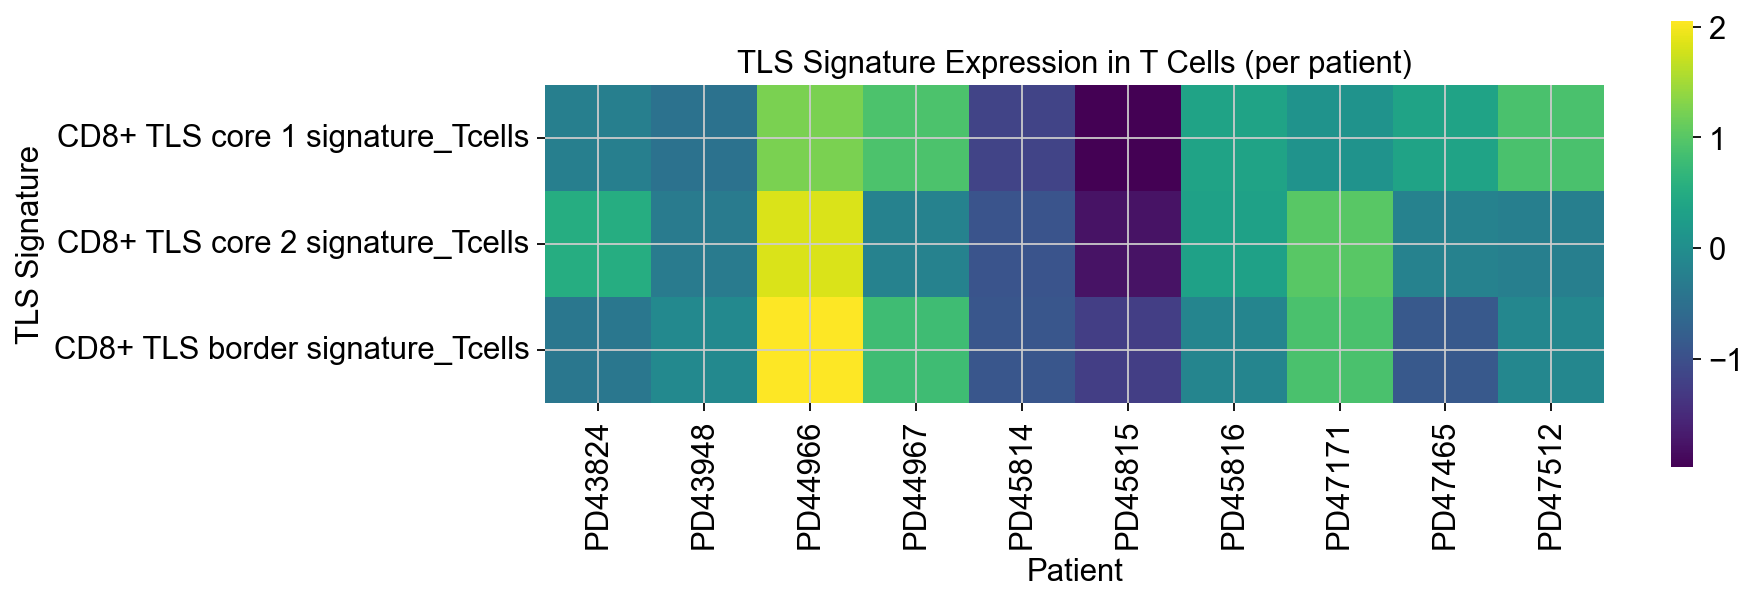

In [312]:
### GENERATES FIGURE 6B

#Test for T cell subsetting

adata_tcells = adata[adata.obs['broad_type'] == 'T-cell'].copy()

sc.tl.score_genes(adata_tcells, gene_list=gene_set1, score_name='CD8+ TLS core 1 signature_Tcells') # Compute the module score
sc.tl.score_genes(adata_tcells, gene_list=gene_set2, score_name='CD8+ TLS core 2 signature_Tcells') # Compute the module score
sc.tl.score_genes(adata_tcells, gene_list=gene_set3, score_name='CD8+ TLS border signature_Tcells') # Compute the module score

sc.pl.dotplot(
    adata_tcells,
    var_names=['CD8+ TLS core 1 signature', 'CD8+ TLS core 2 signature', 'CD8+ TLS border signature'],  # This refers to your computed score in obs
    groupby='patient',
    standard_scale='var',  # Scales the dots for comparability
    color_map="viridis")  # Color scheme

sc.pl.dotplot(
    adata_tcells,
    var_names=['CD8+ TLS core 1 signature_Tcells', 'CD8+ TLS core 2 signature_Tcells', 'CD8+ TLS border signature_Tcells'],  # This refers to your computed score in obs
    groupby='patient',
    standard_scale='var',  # Scales the dots for comparability
    color_map="viridis")  # Color scheme

sc.pl.dotplot(
    adata_tcells,
    var_names=['CD8+ TLS border signature_Tcells'],  # This refers to your computed score in obs
    groupby='patient',
    standard_scale='var',  # Scales the dots for comparability
    color_map="viridis")  # Color scheme



# Step 1: Compute average TLS scores per patient (from T cells only)
agg_scores = (
    adata_tcells.obs
    .groupby('patient')[[
        'CD8+ TLS core 1 signature_Tcells',
        'CD8+ TLS core 2 signature_Tcells',
        'CD8+ TLS border signature_Tcells'
    ]]
    .mean()
)

# Step 2: Standardize across signatures (optional, for comparability)
agg_scores_std = (agg_scores - agg_scores.mean()) / agg_scores.std()

# Step 3: Plot heatmap

plt.figure(figsize=(12, 4))
ax = sns.heatmap(
    agg_scores_std.T,
    cmap='viridis',
    cbar=True,
    linewidths=0,
    linecolor='white',
    xticklabels=False,
    yticklabels=False,
    square=True
)

plt.title('TLS Signature Expression in T Cells (per patient)')
plt.xlabel('Patient')
plt.ylabel('TLS Signature')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 4))
ax = sns.heatmap(
    agg_scores_std.T,
    cmap='viridis',
    cbar=True,
    linewidths=0,
    linecolor='white',
    xticklabels=True,
    yticklabels=True,
    square=True
)

plt.title('TLS Signature Expression in T Cells (per patient)')
plt.xlabel('Patient')
plt.ylabel('TLS Signature')
plt.tight_layout()
plt.show()





/var/folders/d5/cm_lb26s4hqcvy9l5h9g7gjm0000gn/T/ipykernel_36433/1347229347.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


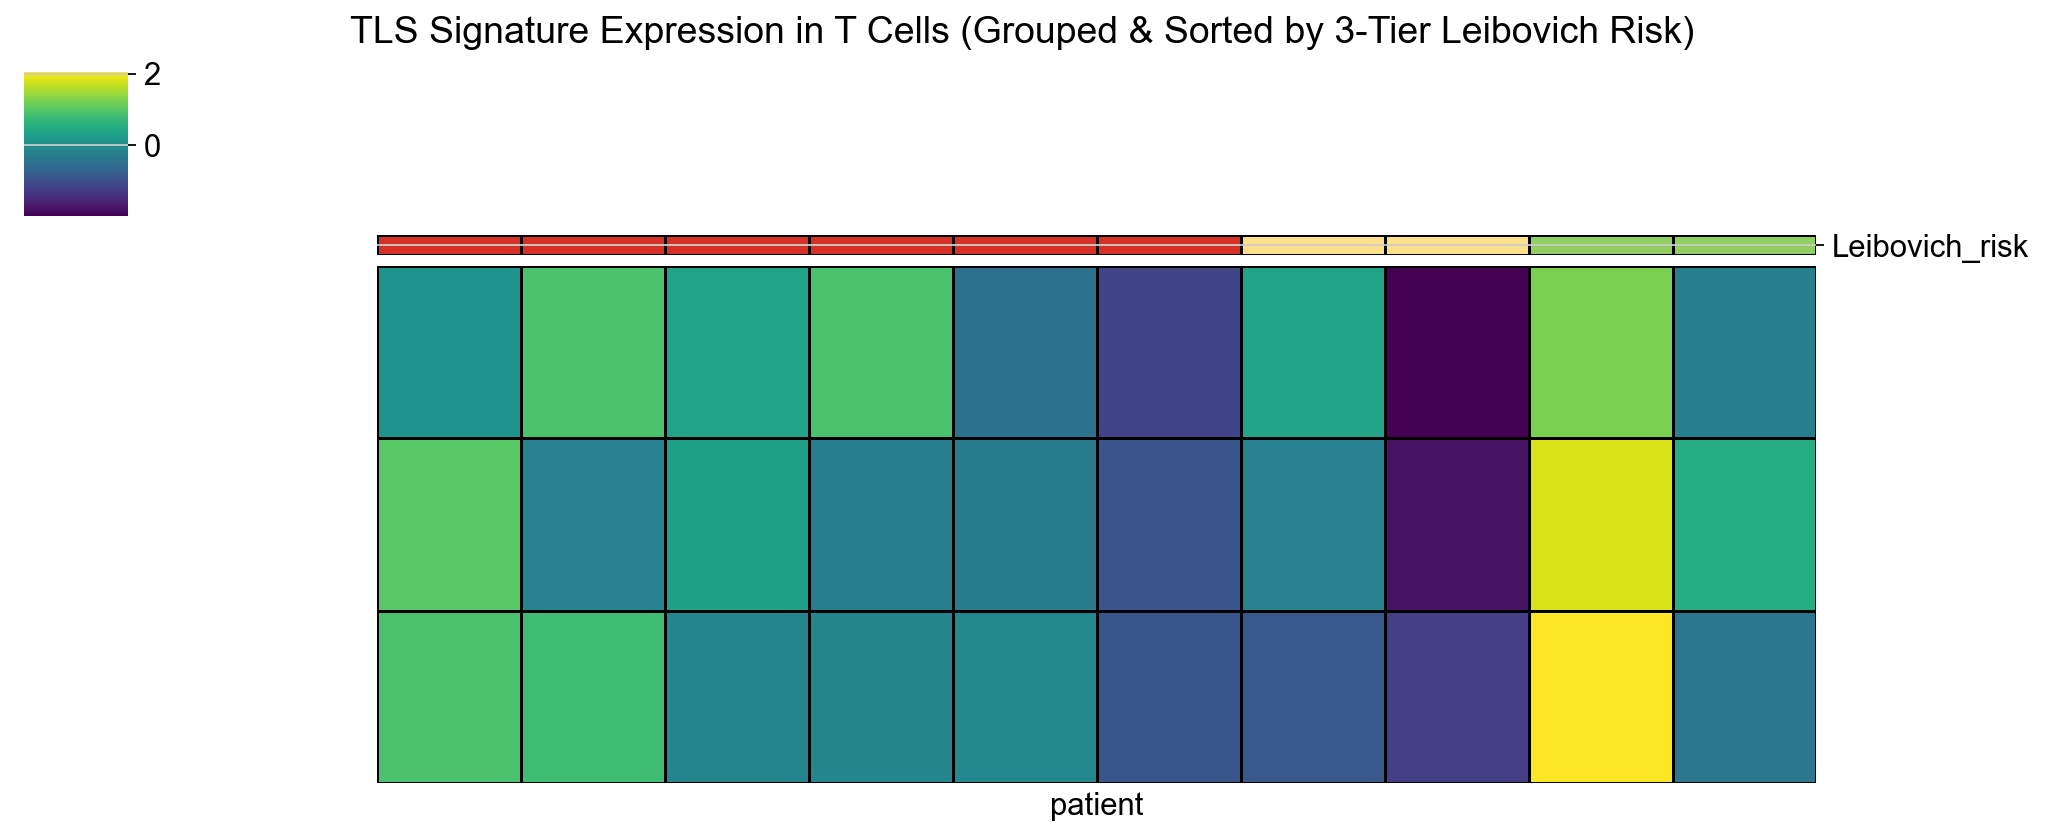

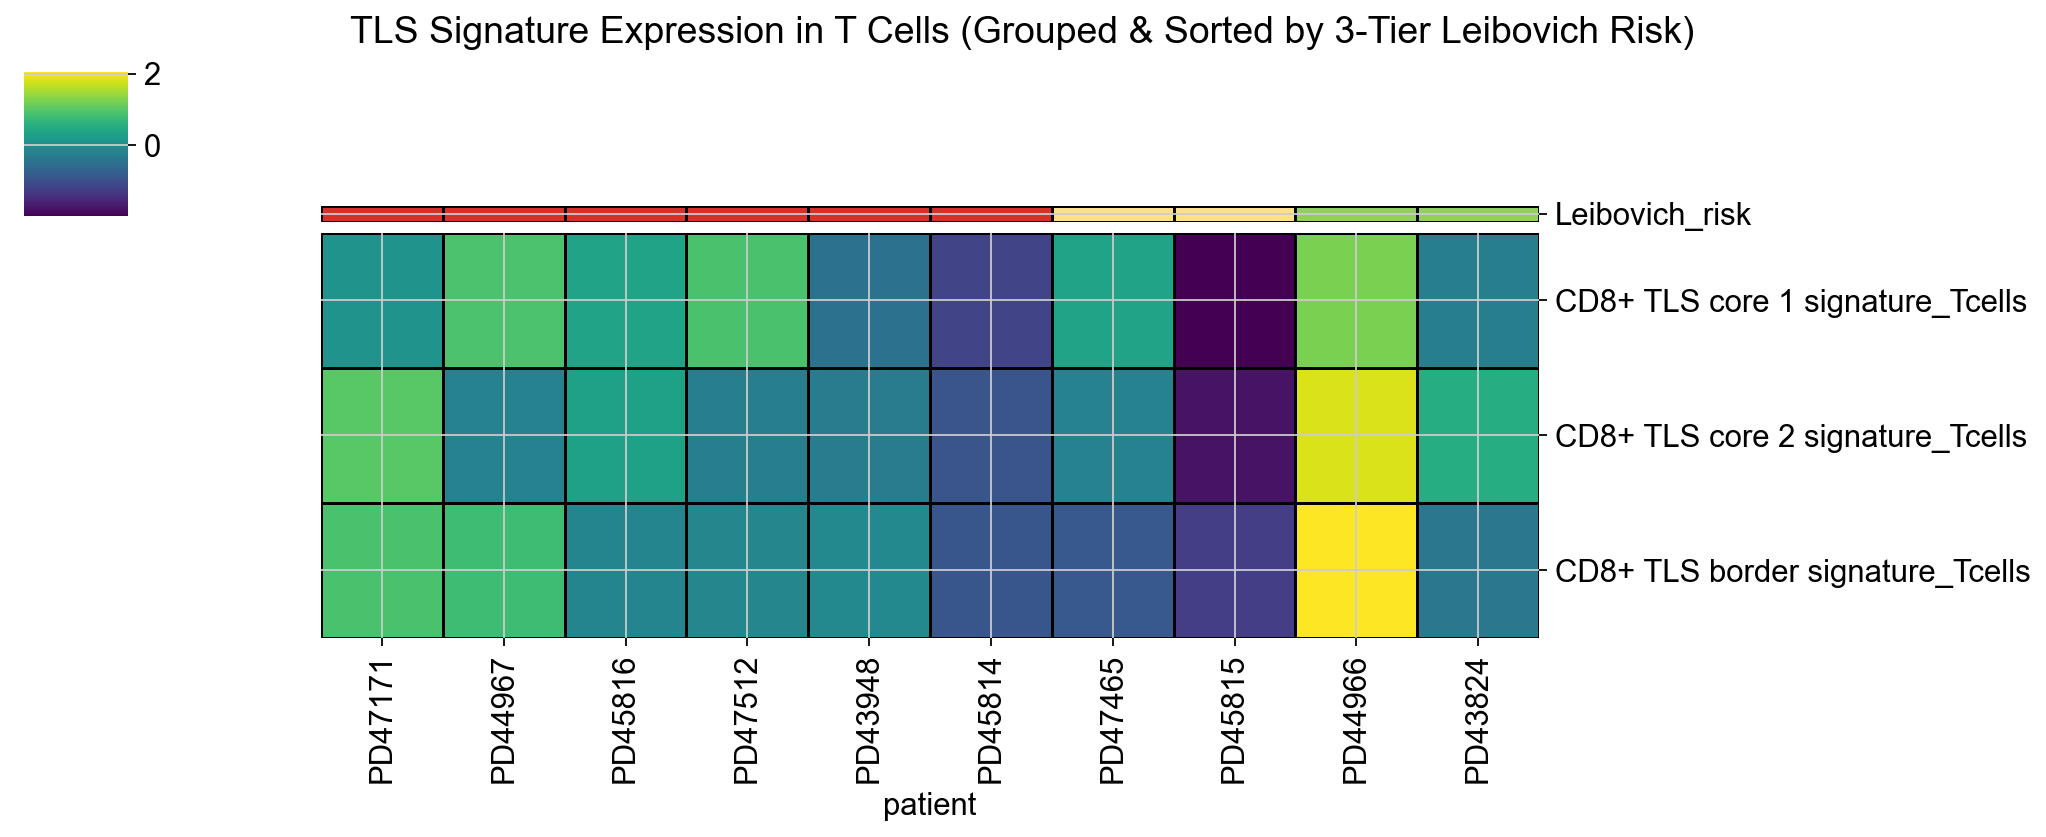

In [315]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Compute average TLS signature scores per patient
agg_scores = (
    adata_tcells.obs
    .groupby('patient')[[
        'CD8+ TLS core 1 signature_Tcells',
        'CD8+ TLS core 2 signature_Tcells',
        'CD8+ TLS border signature_Tcells'
    ]]
    .mean()
)

# Step 2: Standardize scores across features
agg_scores_std = (agg_scores - agg_scores.mean()) / agg_scores.std()

# Step 3: Get updated Leibovich_risk metadata per patient
risk_meta = (
    adata_tcells.obs[['patient', 'Leibovich_risk']]
    .drop_duplicates()
    .set_index('patient')
)

# Step 4: Combine scores and risk into one DataFrame
combined = agg_scores_std.copy()
combined['Leibovich_risk'] = risk_meta['Leibovich_risk']

# Step 5: Sort patients by risk group and TLS score
# Define 3-tier risk order
risk_order = ['Low Risk', 'Intermediate Risk', 'High Risk']
combined['TLS_avg'] = combined[[
    'CD8+ TLS core 1 signature_Tcells',
    'CD8+ TLS core 2 signature_Tcells',
    'CD8+ TLS border signature_Tcells'
]].mean(axis=1)
combined['risk_rank'] = combined['Leibovich_risk'].map({k: i for i, k in enumerate(risk_order)})

# Sort
combined_sorted = combined.sort_values(by=['risk_rank', 'TLS_avg'], ascending=[True, False])
agg_scores_sorted = combined_sorted.drop(columns=['Leibovich_risk', 'TLS_avg', 'risk_rank'])

# Step 6: Define color palette for 3 groups
col_colors = combined_sorted['Leibovich_risk'].map({
    'Low Risk': '#91cf60',         # green
    'Intermediate Risk': '#fee08b',# yellow
    'High Risk': '#d73027'         # red
})

# Step 7: Plot
sns.clustermap(
    agg_scores_sorted.T,
    cmap='viridis',
    col_colors=col_colors,
    linewidths=0.5,
    linecolor='black',
    xticklabels=False,
    yticklabels=False,
    row_cluster=False,
    col_cluster=False,
    figsize=(13, 5)
)

plt.suptitle('TLS Signature Expression in T Cells (Grouped & Sorted by 3-Tier Leibovich Risk)', y=1.05)
plt.show()

sns.clustermap(
    agg_scores_sorted.T,
    cmap='viridis',
    col_colors=col_colors,
    linewidths=0.5,
    linecolor='black',
    xticklabels=True,
    yticklabels=True,
    row_cluster=False,
    col_cluster=False,
    figsize=(13, 5)
)

plt.suptitle('TLS Signature Expression in T Cells (Grouped & Sorted by 3-Tier Leibovich Risk)', y=1.05)
plt.show()


/Users/daniyaljafree/Desktop/scRNAseq_analyses/Lotfollahi_RCC/RCC_DJ_VENV/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


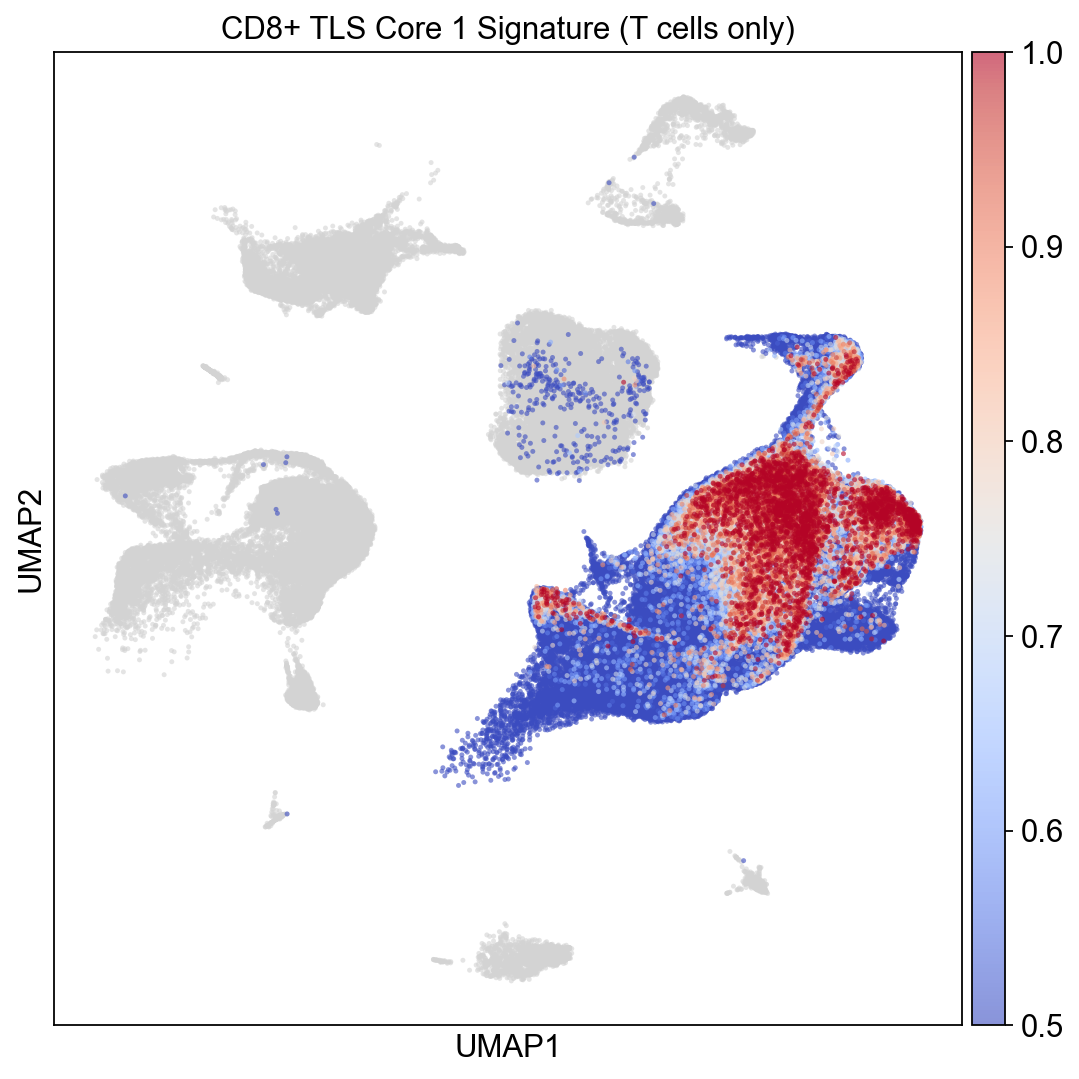

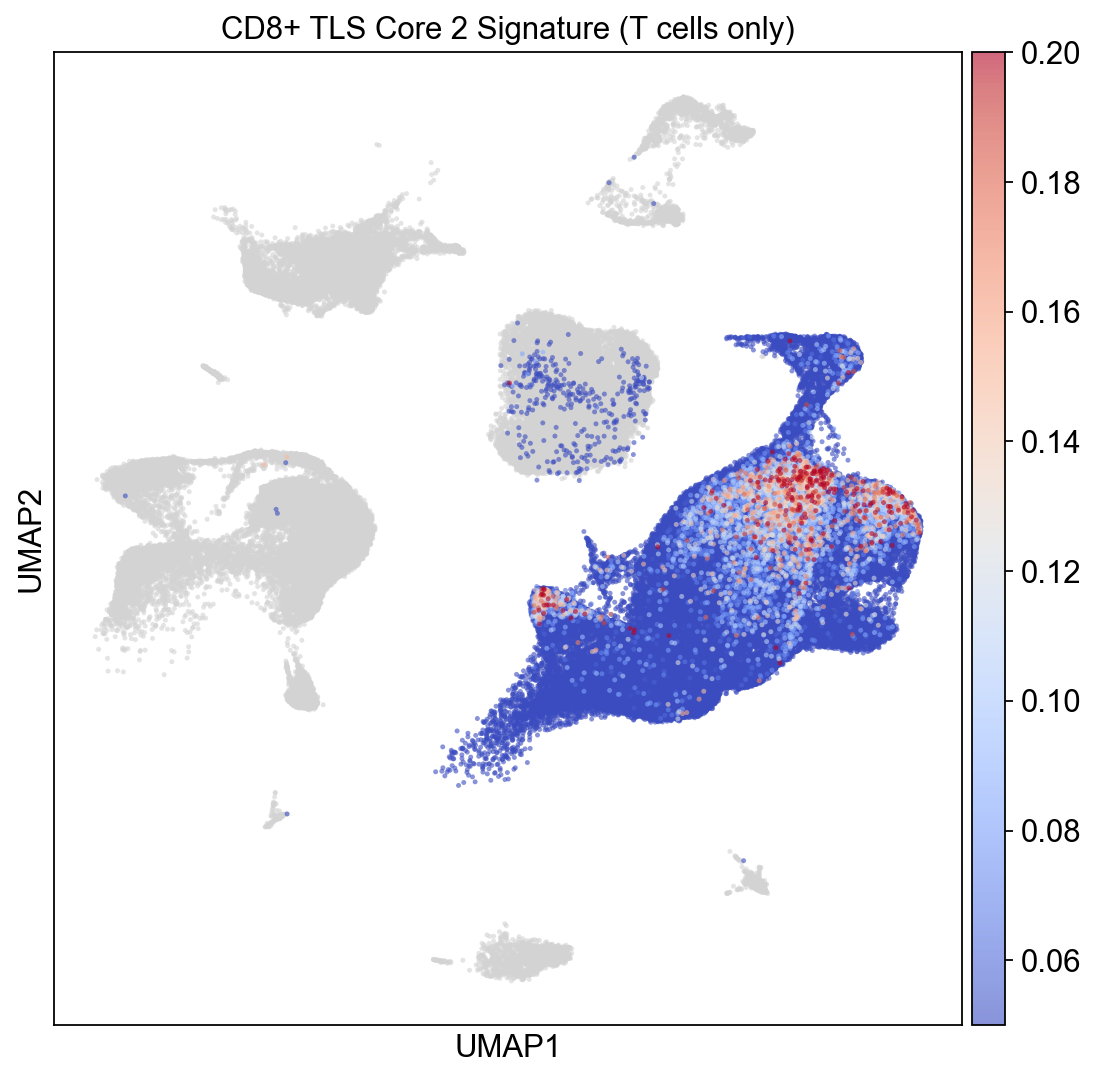

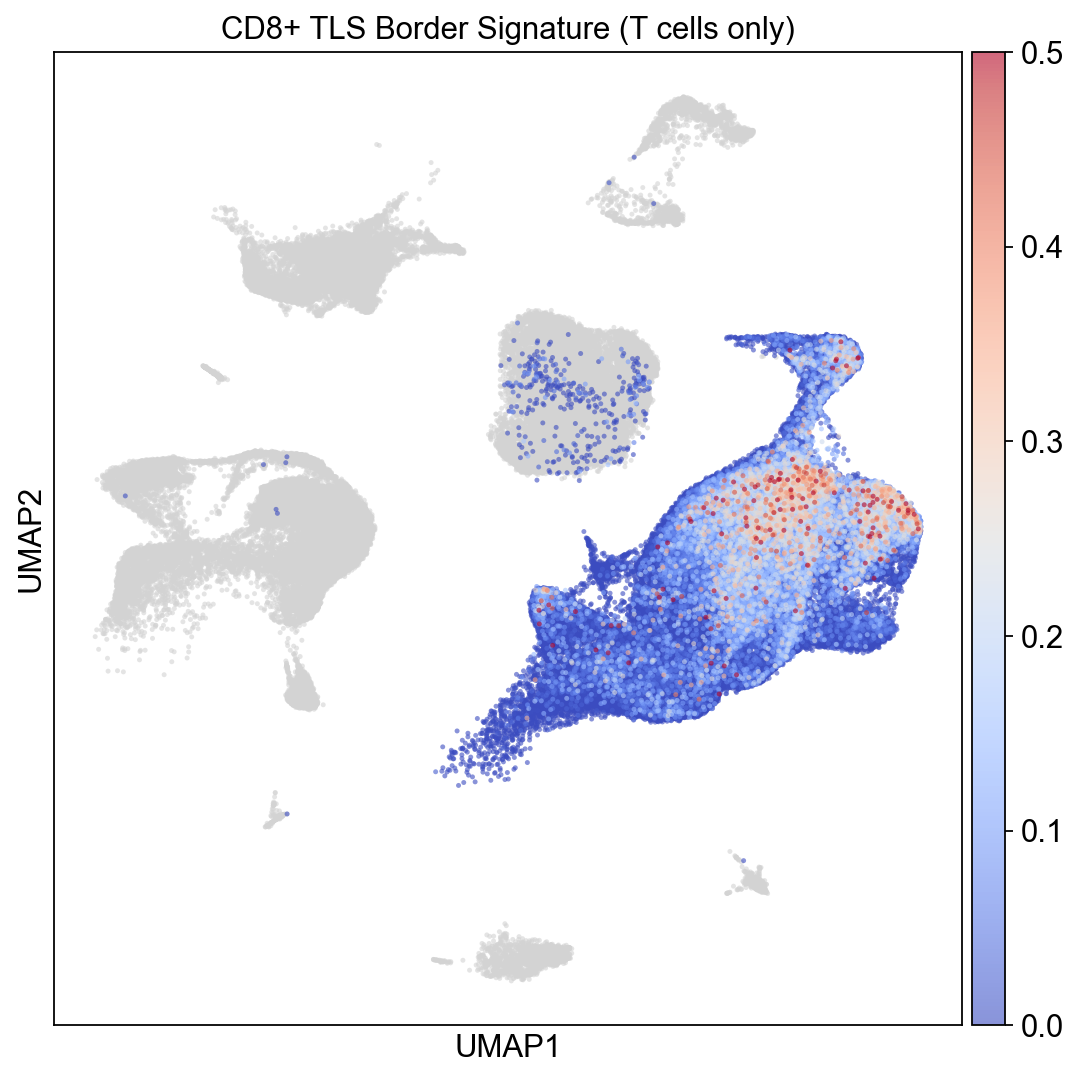

In [84]:
### GENERATES FIGURE 6A

# Step 1: Create a copy of your full adata to modify safely
adata_tcell_masked = adata.copy()

# Step 2: List your module score column names
module_scores = [
    'CD8+ TLS core 1 signature',
    'CD8+ TLS core 2 signature',
    'CD8+ TLS border signature',
    'TLS macrophage signature'
]

# Step 3: Create masked versions in the copied AnnData
for score in module_scores:
    masked_score = f'{score}_Tcells_only'
    adata_tcell_masked.obs[masked_score] = adata_tcell_masked.obs[score]
    adata_tcell_masked.obs.loc[adata_tcell_masked.obs['broad_type'] != 'T-cell', masked_score] = np.nan

# First UMAP
sc.pl.umap(
    adata_tcell_masked,
    color='CD8+ TLS core 1 signature_Tcells_only',
    cmap='coolwarm',
    na_color='lightgrey',
    vmin=0.5, vmax=1,  # Adjust this threshold as needed
    title='CD8+ TLS Core 1 Signature (T cells only)', size=20, alpha=0.6
)

# Second UMAP
sc.pl.umap(
    adata_tcell_masked,
    color='CD8+ TLS core 2 signature_Tcells_only',
    cmap='coolwarm',
    na_color='lightgrey',
    vmin=0.05, vmax=0.2,
    title='CD8+ TLS Core 2 Signature (T cells only)', size=20, alpha=0.6
)

# Third UMAP
sc.pl.umap(
    adata_tcell_masked,
    color='CD8+ TLS border signature_Tcells_only',
    cmap='coolwarm',
    na_color='lightgrey',
    vmin=0, vmax=0.5,
    title='CD8+ TLS Border Signature (T cells only)', size=20, alpha=0.6
)

In [192]:
# Start with a copy of broad_type
adata.obs['new_labels'] = adata.obs['broad_type'].copy()

# Add TLS_Tcell and non-TLS T-cell labels if it's a Categorical
if pd.api.types.is_categorical_dtype(adata.obs['new_labels']):
    adata.obs['new_labels'] = adata.obs['new_labels'].cat.add_categories(['TLS_Tcell', 'non-TLS T-cell'])

# Define thresholds
thresholds = {
    'CD8+ TLS core 1 signature': 1.0,
    'CD8+ TLS core 2 signature': 0.1,
    'CD8+ TLS border signature': 0.3
}

# Build mask for ANY TLS module score above threshold
tls_mask = (
    (adata.obs['broad_type'] == 'T-cell') & (
        (adata.obs['CD8+ TLS core 1 signature'] > thresholds['CD8+ TLS core 1 signature']) |
        (adata.obs['CD8+ TLS core 2 signature'] > thresholds['CD8+ TLS core 2 signature']) |
        (adata.obs['CD8+ TLS border signature'] > thresholds['CD8+ TLS border signature'])
    )
)

# Assign labels
adata.obs.loc[tls_mask, 'new_labels'] = 'TLS_Tcell'
adata.obs.loc[
    (adata.obs['broad_type'] == 'T-cell') & (~tls_mask),
    'new_labels'
] = 'non-TLS T-cell'


/var/folders/d5/cm_lb26s4hqcvy9l5h9g7gjm0000gn/T/ipykernel_36433/1974511181.py:5: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead


In [211]:
## Keep only cells that are not Epi_non-PT or Epi_PT
adata = adata[~adata.obs['new_labels'].isin(['Epi_non-PT', 'Epi_PT', 'pDC'])].copy()

In [212]:
adata.obs['new_labels'].value_counts()

new_labels
non-TLS T-cell    88376
Myeloid           20391
NK                18526
RCC               11915
TLS_Tcell          4435
B-cell             1419
EC                 1202
Fibro               538
Plasma              474
Mast                410
Name: count, dtype: int64

In [213]:
# Check if data is already norm
adata.X.sum(1)

matrix([[372.8838 ],
        [271.05902],
        [376.45093],
        ...,
        [495.5862 ],
        [496.65097],
        [500.59836]], dtype=float32)

In [214]:
sc.pp.normalize_total(adata, inplace=True)

normalizing counts per cell
    finished (0:00:01)


In [215]:
print(f"Min: {adata.X.min()}, Max: {adata.X.max()}, Mean: {adata.X.mean()}")

Min: 0.0, Max: 2.84112548828125, Mean: 0.023140523582696915


In [216]:
# Logarithmize the data
sc.pp.log1p(adata)

In [217]:
print(f"Min: {adata.X.min()}, Max: {adata.X.max()}, Mean: {adata.X.mean()}")

Min: 0.0, Max: 1.345765471458435, Mean: 0.01926407404243946


In [218]:
li.mt.rank_aggregate(adata, groupby='new_labels', expr_prop=0.1, verbose=True, use_raw=False)

Using resource `consensus`.
Using `.X`!
Converting to sparse csr matrix!
/Users/daniyaljafree/Desktop/scRNAseq_analyses/Lotfollahi_RCC/RCC_DJ_VENV/lib/python3.10/site-packages/anndata/_core/anndata.py:401: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
561 features of mat are empty, they will be removed.
/Users/daniyaljafree/Desktop/scRNAseq_analyses/Lotfollahi_RCC/RCC_DJ_VENV/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:150: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
/Users/daniyaljafree/Desktop/scRNAseq_analyses/Lotfollahi_RCC/RCC_DJ_VENV/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
0.23 of entities in the resource are mis

Generating ligand-receptor stats for 147686 samples and 1368 features
... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


/Users/daniyaljafree/Desktop/scRNAseq_analyses/Lotfollahi_RCC/RCC_DJ_VENV/lib/python3.10/site-packages/liana/method/sc/_liana_pipe.py:262: ImplicitModificationWarning: Setting element `.layers['scaled']` of view, initializing view as actual.


Assuming that counts were `natural` log-normalized!
Running CellPhoneDB


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:18<00:00, 12.75it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [219]:
adata.uns['liana_res'].head()

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,specificity_rank,magnitude_rank
5654,Plasma,NK,B2M,KLRD1,0.627573,0.0,0.335314,2.836043,0.540704,0.129492,0.966893,0.009610,1.300991e-07
5676,Plasma,NK,HLA-B,KLRD1,0.590785,0.0,0.306941,2.506624,0.516798,0.129920,0.965448,0.015368,5.203547e-07
1541,EC,Plasma,APP,CD74,0.570078,0.0,0.282421,2.518349,0.536416,0.076567,0.964032,0.011530,1.170704e-06
5755,Plasma,TLS_Tcell,HLA-C,CD8A,0.566999,0.0,0.267899,1.909382,0.371345,0.076009,0.963106,0.108533,2.081085e-06
5752,Plasma,TLS_Tcell,HLA-B,CD8A,0.565721,0.0,0.267042,1.859622,0.353557,0.071877,0.963049,0.108761,3.251435e-06


In [220]:
rank_aggregate.describe()

Rank_Aggregate returns `magnitude_rank`, `specificity_rank`. magnitude_rank and specificity_rank respectively represent an aggregate of the `magnitude`- and `specificity`-related scoring functions from the different methods.


/Users/daniyaljafree/Desktop/scRNAseq_analyses/Lotfollahi_RCC/RCC_DJ_VENV/lib/python3.10/site-packages/liana/plotting/_common.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


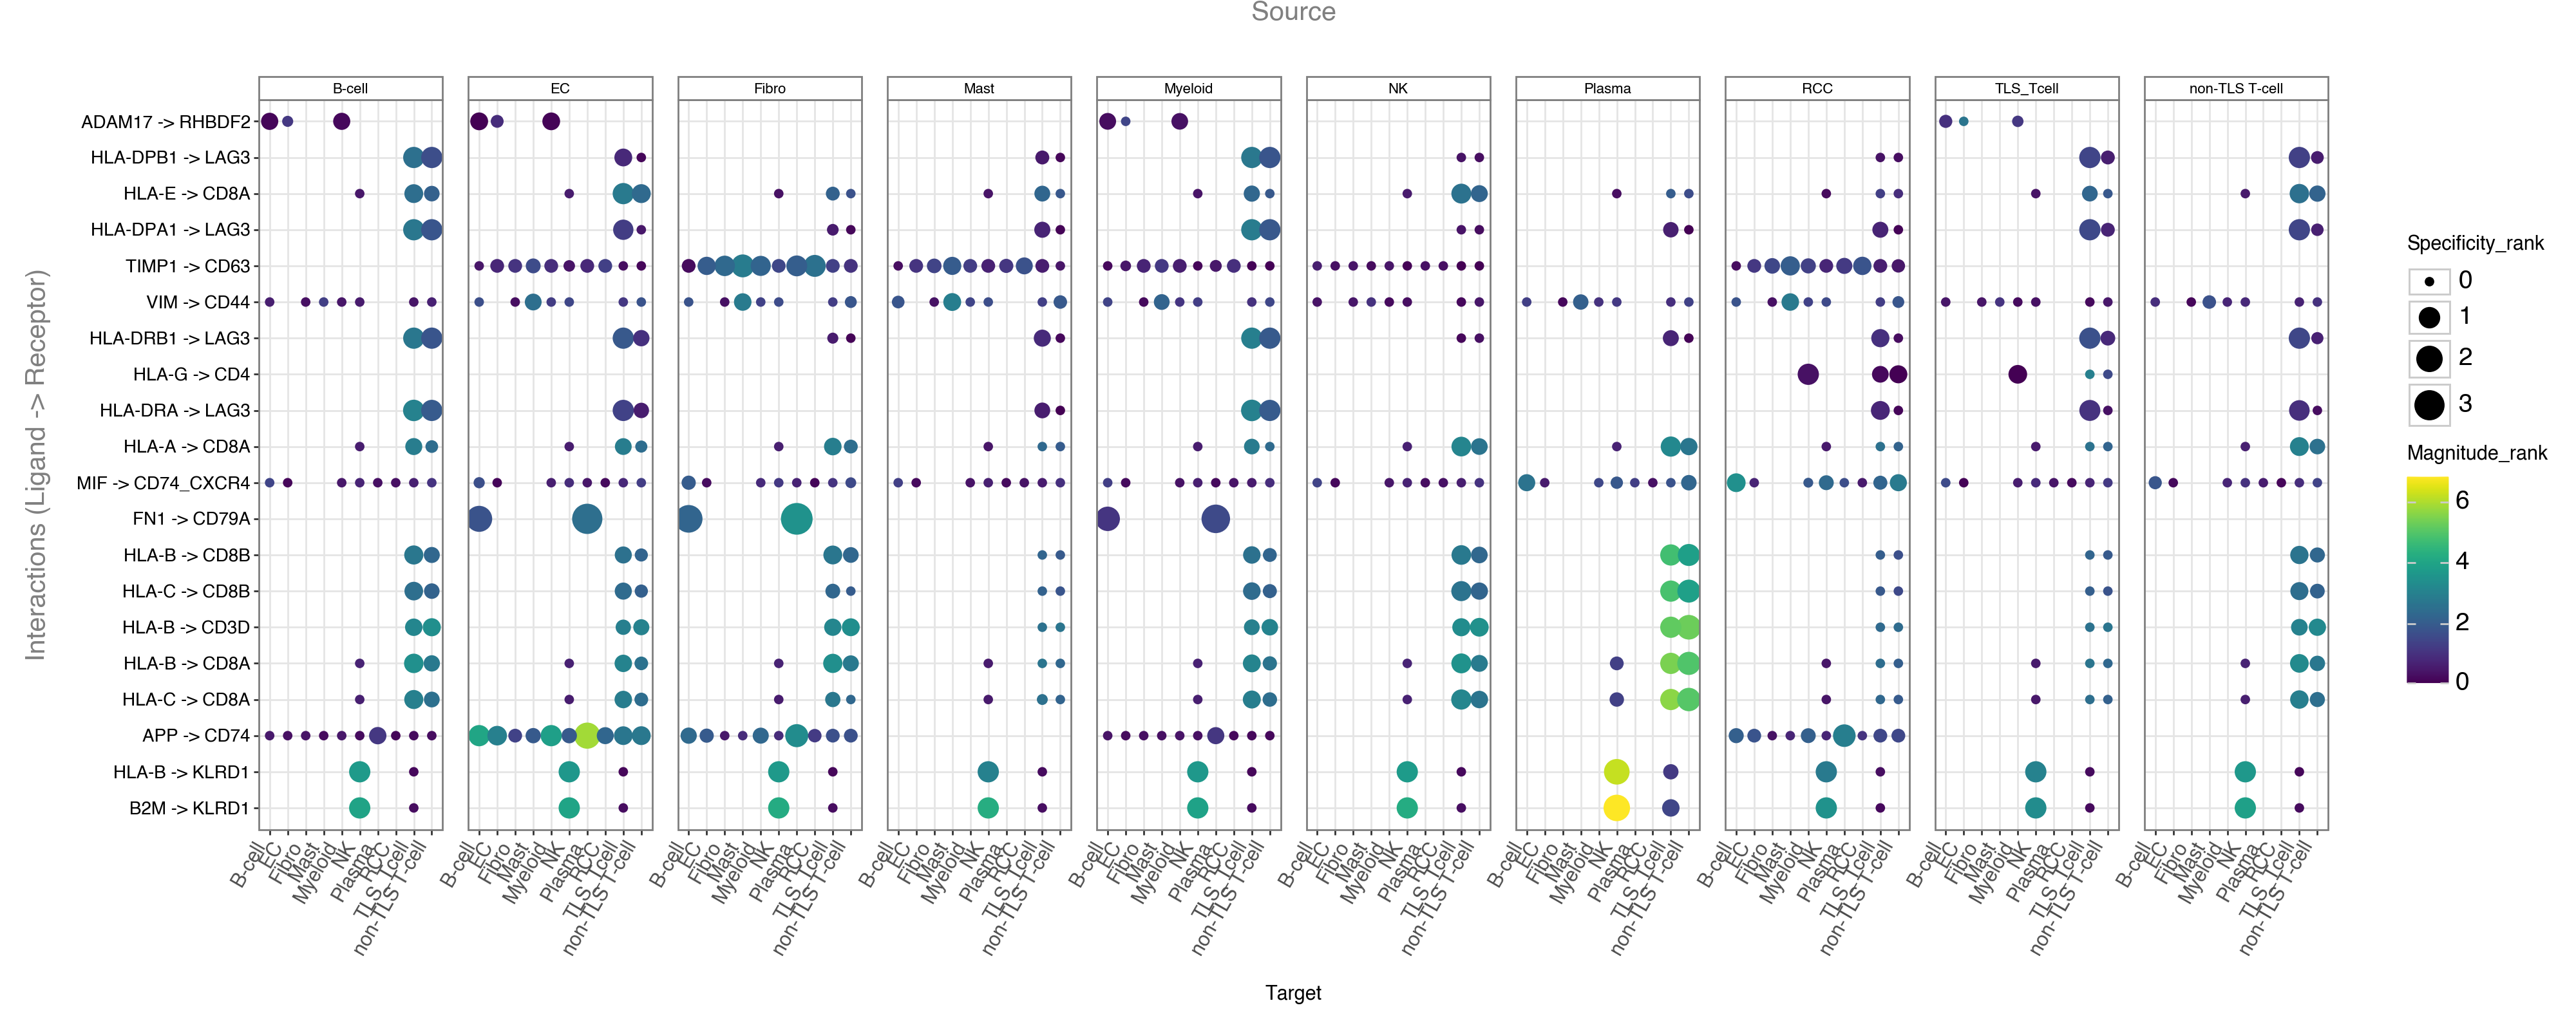

In [221]:
my_plot = li.pl.dotplot(adata = adata,
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              # source_labels=['Spatially_defined_OPC', 
              #                'Hypoxic', 
              #                'Lymphocytes', 
              #                'Macrophages'],
              # target_labels=['Spatially_defined_OPC', 
              #                'Hypoxic', 
              #                'Lymphocytes', 
              #                'Macrophages'],
              top_n=20,
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(20, 8)
             )

my_plot

plot = (my_plot +
 p9.theme(
     # adjust facet size
     strip_text=p9.element_text(size=8),
     # rotate labels on x axis
     axis_text_x=p9.element_text(rotation=60, hjust=1)
 )
)

plot

<Axes: >

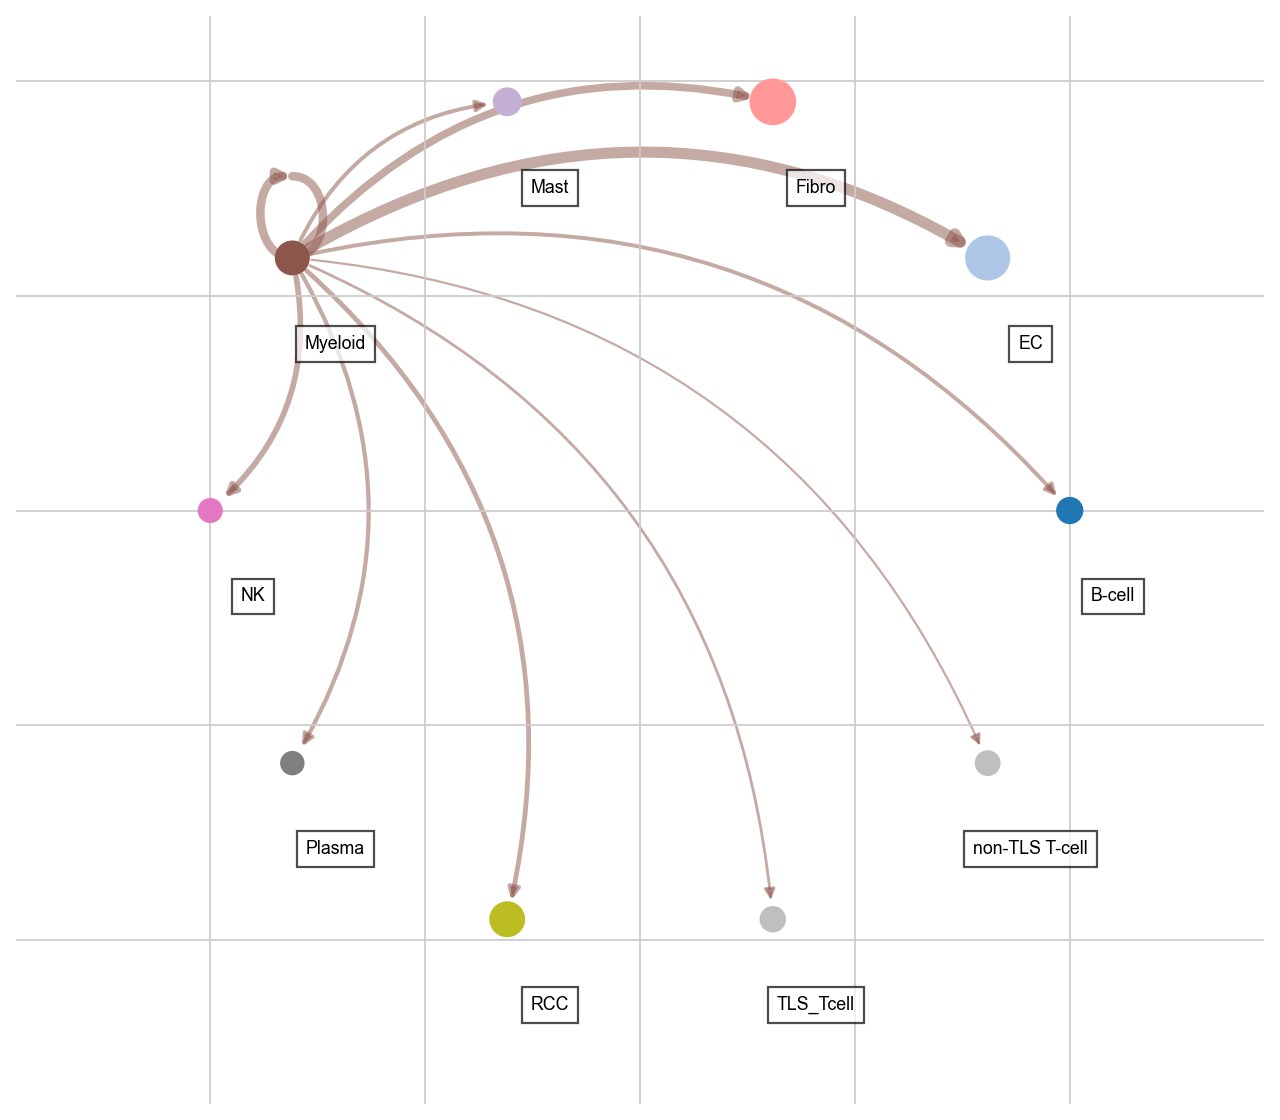

In [222]:
li.pl.circle_plot(adata,
                  groupby='new_labels',
                  score_key='magnitude_rank',
                  inverse_score=True,
                  source_labels='Myeloid',
                  filter_fun=lambda x: x['specificity_rank'] <= 0.05,
                  pivot_mode='counts', # NOTE: this will simply count the interactions, 'mean' is also available
                  figure_size=(10, 10),
                  )

In [223]:
cell_types = set(adata.obs['new_labels'])
cell_types

{'B-cell',
 'EC',
 'Fibro',
 'Mast',
 'Myeloid',
 'NK',
 'Plasma',
 'RCC',
 'TLS_Tcell',
 'non-TLS T-cell'}

In [225]:
# Get broad_type colors
broad_colors = adata.uns['broad_type_colors']
broad_categories = adata.obs['broad_type'].cat.categories

# Map category → color
broad_color_dict = dict(zip(broad_categories, broad_colors))

# Assign the same colors to matching new_labels (e.g. non-TLS T-cell, TLS_Tcell, Macrophage, etc.)
new_label_categories = adata.obs['new_labels'].cat.categories
new_label_colors = [broad_color_dict.get(cat, '#BFBFBF') for cat in new_label_categories]  # default grey if missing

# Save color mapping to 'new_labels_colors' (Scanpy convention)
adata.uns['new_labels_colors'] = new_label_colors


Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt
Fontsize 0.00 < 1.0 pt not allowed by FreeType. Setting fontsize = 1 pt


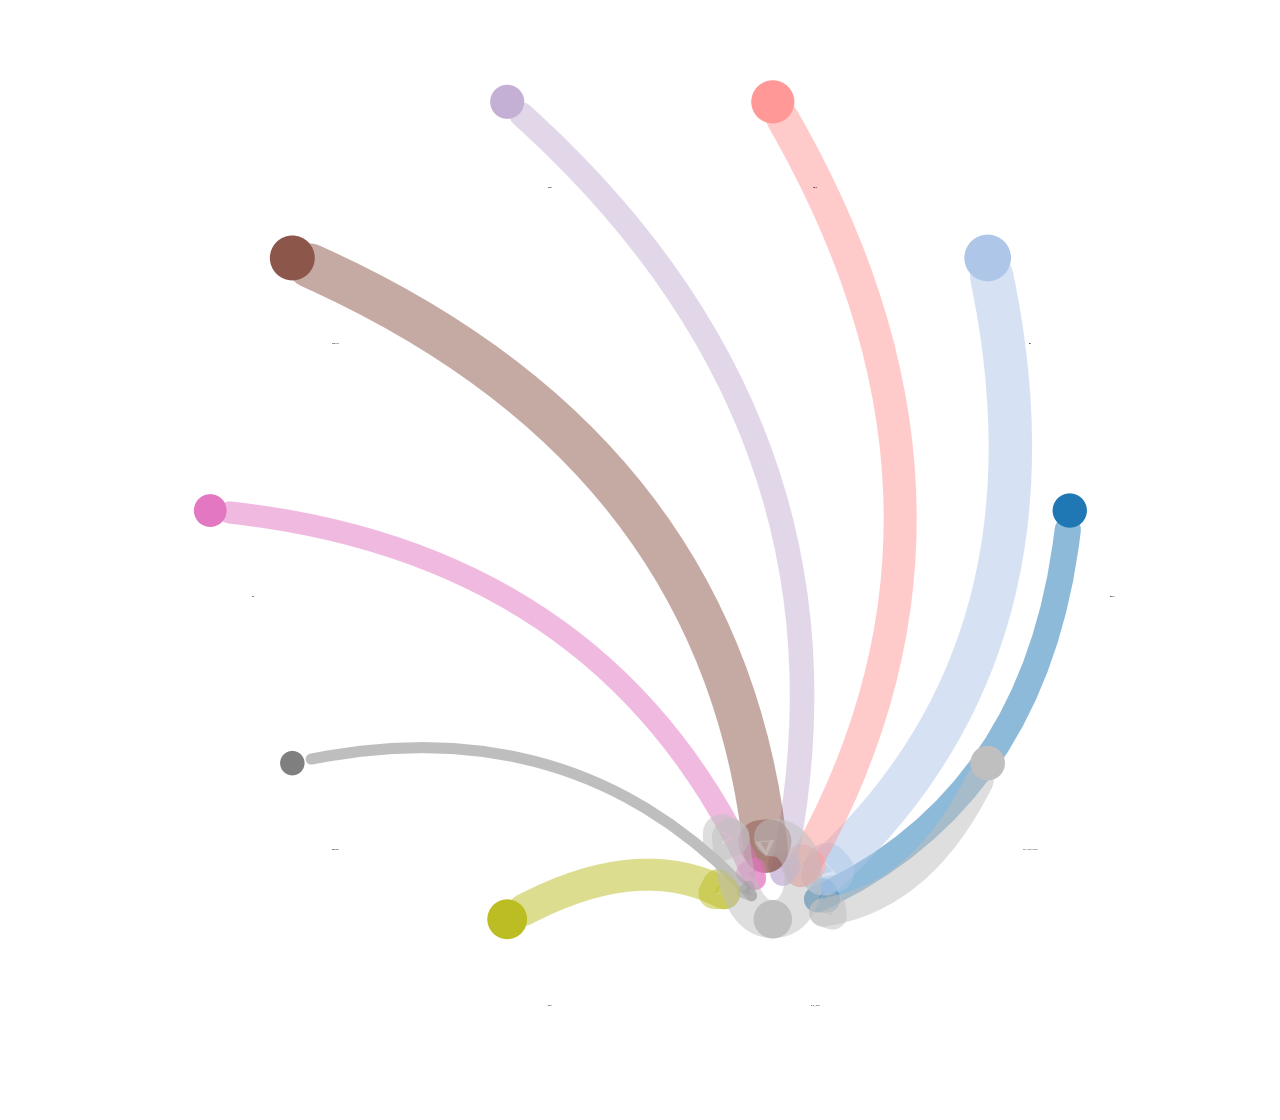

In [243]:
### GENERATES FIGURE 6C

ax = li.pl.circle_plot(
    adata,
    groupby='new_labels',
    score_key='magnitude_rank',
    inverse_score=False,
    target_labels='TLS_Tcell',
    filter_fun=lambda x: x['specificity_rank'] <= 0.5,
    pivot_mode='counts',
    figure_size=(10, 10),
    edge_width_scale=(5, 20),
    node_label_size=0,
    node_label_alpha=0
)

# Optional: clean aesthetics
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(False)
ax.set_frame_on(False)
ax.axis('off')

plt.show()


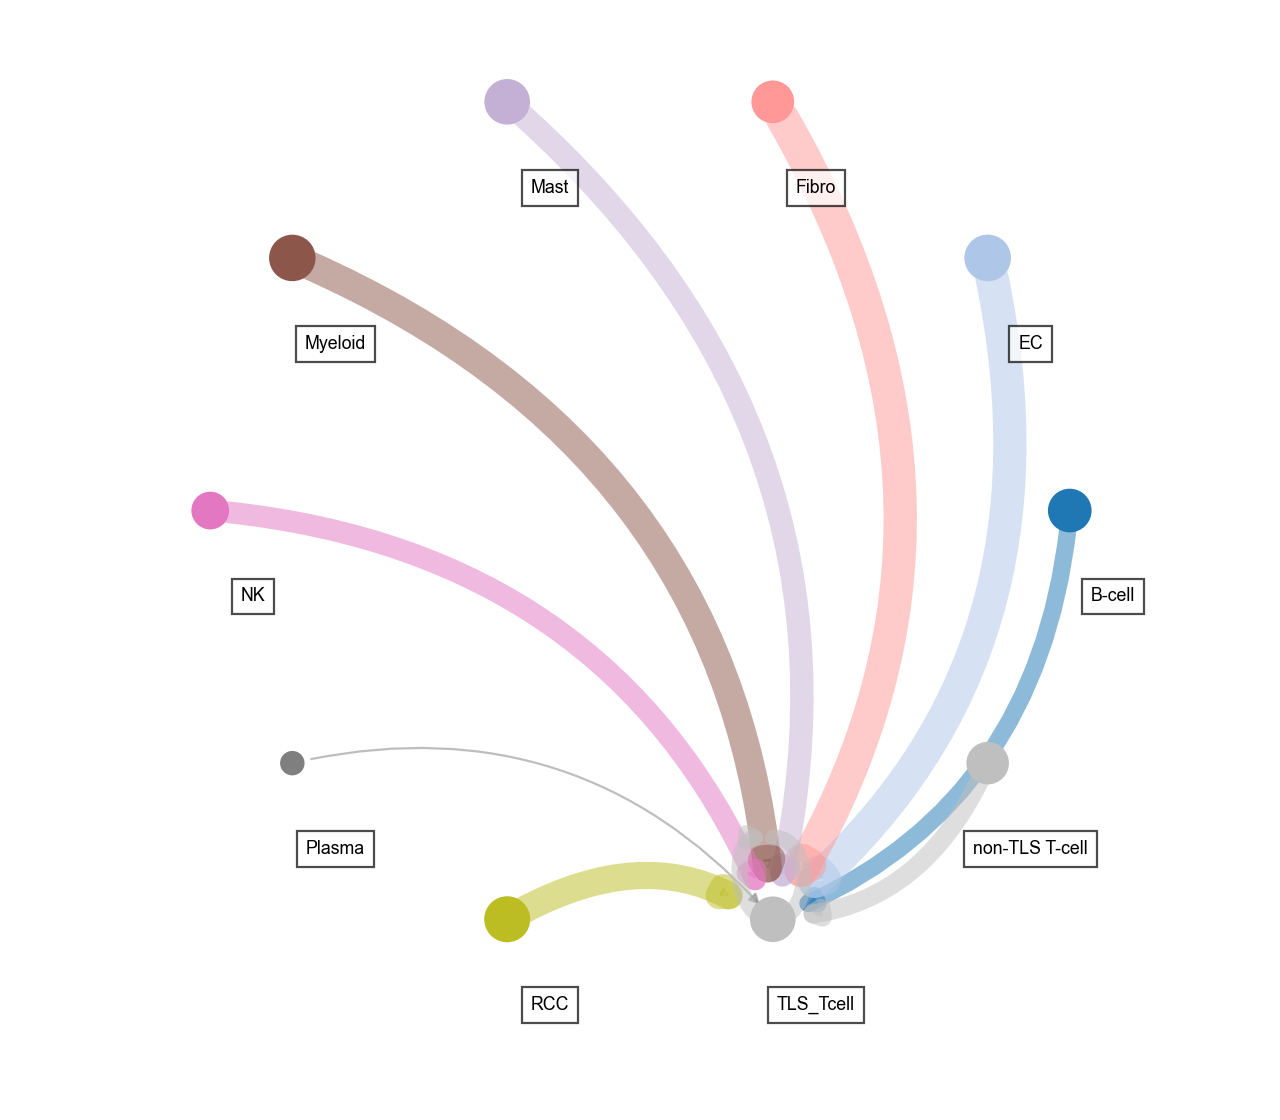

In [235]:
### GENERATES FIGURE 6C (with labels for orientation)

ax = li.pl.circle_plot(
    adata,
    groupby='new_labels',
    score_key='magnitude_rank',
    inverse_score=False,
    target_labels='TLS_Tcell',
    filter_fun=lambda x: x['specificity_rank'] <= 0.1,
    pivot_mode='mean',
    figure_size=(10, 10),
    edge_width_scale=(1, 15),
    #node_label_size=0,
    #node_label_alpha=0
)

# Optional: clean aesthetics
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.grid(False)
ax.set_frame_on(False)
ax.axis('off')

plt.show()


/Users/daniyaljafree/Desktop/scRNAseq_analyses/Lotfollahi_RCC/RCC_DJ_VENV/lib/python3.10/site-packages/liana/plotting/_common.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


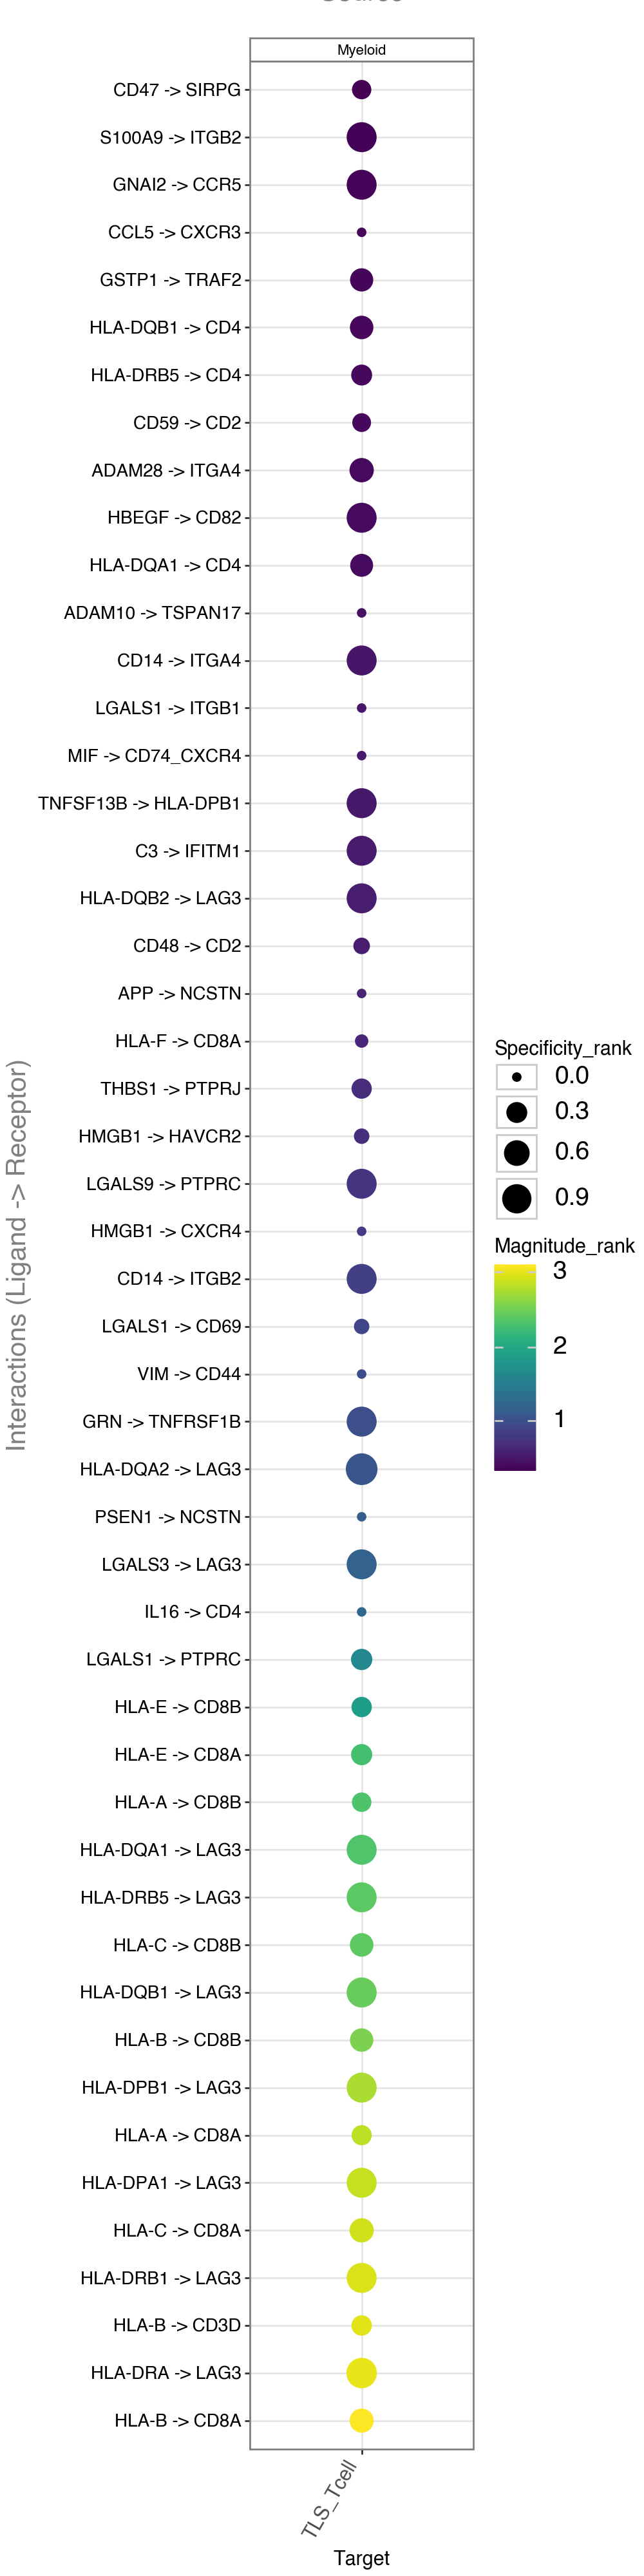

In [294]:
### GENERATES FIGURE SUPPLEMENTARY S12

my_plot = li.pl.dotplot(adata = adata,
              colour='magnitude_rank',
              size='specificity_rank',
              inverse_size=True,
              inverse_colour=True,
              source_labels=['Myeloid'],
              target_labels=['TLS_Tcell'
                            ],
              top_n=50,
              orderby='magnitude_rank',
              orderby_ascending=True,
              figure_size=(5, 20)
             )

my_plot

plot = (my_plot +
 p9.theme(
     # adjust facet size
     strip_text=p9.element_text(size=8),
     # rotate labels on x axis
     axis_text_x=p9.element_text(rotation=60, hjust=1)
 )
)

plot